# Setting up data and paths

In [33]:
# connecting to the drive

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [34]:
# adding path to CSVs

import csv
import pandas as pd
import numpy as np
from datetime import timedelta
import os

!ls '/content/drive/MyDrive/25 Fall/BME499 - Senior Capstone/499 Senior Project Group - RaGS/Code/CSV Files'

datapath = '/content/drive/MyDrive/25 Fall/BME499 - Senior Capstone/499 Senior Project Group - RaGS/Code/CSV Files/';

# PARAMETERS
# ---------------------------

N_HOURS = 4          # length of each bin (hours)
N_BINS = 3           # number of temporal bins
AGG_FUN = 'mean'                # aggregation per bin



 ADMISSIONS.csv       D_ICD_DIAGNOSES.csv      NOTEEVENTS.csv
 CALLOUT.csv	      D_ITEMS.csv	       OUTPUTEVENTS.csv
 CAREGIVERS.csv       D_LABITEMS.csv	       PATIENTS.csv
 CHARTEVENTS.csv      DRGCODES.csv	       preprocess_stats.npz
 checkpoints	      ICUSTAYS.csv	       PRESCRIPTIONS.csv
 CPTEVENTS.csv	      INPUTEVENTS_CV.csv       PROCEDUREEVENTS_MV.csv
 DATETIMEEVENTS.csv   INPUTEVENTS_MV.csv      'processed CSVs'
 D_CPT.csv	      LABEVENTS.csv	       sepsis_mlp.pt
 DIAGNOSES_ICD.csv    MICROBIOLOGYEVENTS.csv   SERVICES.csv


In [35]:
# create vectors to store hadm-id's we want to use for training

def remove_duplicates(arr):
    """Remove duplicate values from an array while preserving order."""
    seen = set()
    unique = []
    for x in arr:
        if x not in seen:
            unique.append(x)
            seen.add(x)
    return unique


# get list of hadmids from list of subject ids Rachael provided
path = '/content/drive/MyDrive/25 Fall/BME499 - Senior Capstone/499 Senior Project Group - RaGS/train1_small_subject_ids.csv'
subject_ids = pd.read_csv(path).iloc[:, 0].tolist()
#print(subject_ids)

path = f"{datapath}/{'ADMISSIONS.csv'}"
admissions = pd.read_csv(path);
#print(admissions)
trainingset_1 = ( admissions.loc[admissions["SUBJECT_ID"].astype(int).isin(subject_ids), "HADM_ID"]
    .unique())
training_id = trainingset_1.tolist()

# training_id = set(training_set.astype("Int64").astype(str))
# print(training_set)
print(len(training_id))
print(len(subject_ids))

trainingset_1.tofile(f"{datapath}/processed CSVs/trainingset_1.csv")

# Demo list of training_ids





2856
2418


In [36]:
# Creating more sets of hadm-id's

import numpy as np
import pandas as pd

ADMISSIONS_PATH = f"{datapath}/ADMISSIONS.csv"
# trainingset_1 = pd.read_csv()

# trainingset1 = [...]  # your existing list/series of HADM_IDs
trainingset1_set = set(pd.Series(trainingset_1, dtype="string").str.strip().dropna().tolist())

# ---- Stream ADMISSIONS.csv in chunks and collect HADM_IDs not in trainingset1 ----
remaining_ids = []

chunksize = 500_000  # adjust if needed

for chunk in pd.read_csv(
    ADMISSIONS_PATH,
    usecols=["HADM_ID"],
    dtype={"HADM_ID": "string"},
    chunksize=chunksize
):
    chunk["HADM_ID"] = chunk["HADM_ID"].str.strip()
    # keep only ids not in trainingset1
    keep = chunk.loc[~chunk["HADM_ID"].isin(trainingset1_set), "HADM_ID"]
    remaining_ids.extend(keep.dropna().tolist())

# Deduplicate (ADMISSIONS should already be unique, but safe)
remaining = pd.Series(remaining_ids, dtype="string").dropna().unique()

print("Remaining unique admissions:", len(remaining))

required = 5 * 2500
assert len(remaining) >= required, f"Not enough remaining admissions (need {required})"

# ---- Sample 5 non-overlapping sets of 2500 ----
rng = np.random.default_rng(seed=42)
shuffled = rng.permutation(remaining)

groups = {}
for i in range(5):
    start = i * 2500
    end = start + 2500
    groups[f"trainingset_{i+2}"] = shuffled[start:end]

print({k: len(v) for k, v in groups.items()})

# ---- Optional: verify no overlaps ----
for name, ids in groups.items():
    assert len(set(ids) & trainingset1_set) == 0, f"Overlap with trainingset1 in {name}"

for i in range(5):
    for j in range(i + 1, 5):
        a = set(groups[f"trainingset_{i+2}"])
        b = set(groups[f"trainingset_{j+2}"])
        assert len(a & b) == 0, f"Overlap between trainingset_{i+2} and trainingset_{j+2}"

print("No overlaps anywhere ✅")

# ---- Save to CSV ----
for name, ids in groups.items():
    pd.DataFrame({"HADM_ID": ids}).to_csv(f"{datapath}/processed CSVs/{name}.csv", index=False)

print("Saved to /content/:", ", ".join([f"{k}.csv" for k in groups.keys()]))


Remaining unique admissions: 56120
{'trainingset_2': 2500, 'trainingset_3': 2500, 'trainingset_4': 2500, 'trainingset_5': 2500, 'trainingset_6': 2500}
No overlaps anywhere ✅
Saved to /content/: trainingset_2.csv, trainingset_3.csv, trainingset_4.csv, trainingset_5.csv, trainingset_6.csv


In [37]:
# HELPER FUNCTIONS
# ---------------------------

# def load_filtered_csv(filename, usecols=None):
#     """Load CSV, keep only rows with HADM_ID in training_id."""
#     path = f"{datapath}/{filename}"

#     dtype_overrides = {
#         'SUBJECT_ID': 'string',
#         'HADM_ID': 'string',
#         'ICUSTAY_ID': 'string',
#         'ITEMID': 'string',
#         'ROW_ID': 'string',
#         'DOB': 'string'
#     }

#     df = pd.read_csv(path, usecols=usecols, dtype=dtype_overrides)
#     df.columns = df.columns.str.strip().str.upper()
#     if 'HADM_ID' in df.columns:
#         df = df[df['HADM_ID'].isin([str(x) for x in training_id])]
#     return df

# loading it in chunks for lower memory
def load_filtered_csv_stream(
    filename,
    training_id,
    usecols=None,
    chunksize=300_000
):
    """
    Stream CSV in chunks and keep only rows with HADM_ID in training_id.
    """

    path = f"{datapath}/{filename}"

    # Convert once for fast lookup
    training_id_set = set(str(x) for x in training_id)

    dtype_overrides = {
        'SUBJECT_ID': 'string',
        'HADM_ID': 'string',
        'ICUSTAY_ID': 'string',
        'ITEMID': 'string',
        'ROW_ID': 'string',
        'DOB': 'string'
    }

    filtered_chunks = []

    for chunk in pd.read_csv(
        path,
        usecols=usecols,
        dtype=dtype_overrides,
        chunksize=chunksize,
        low_memory=False
    ):
        # Normalize column names per chunk
        chunk.columns = chunk.columns.str.strip().str.upper()

        # Filter only if HADM_ID exists
        if 'HADM_ID' in chunk.columns:
            chunk = chunk[chunk['HADM_ID'].isin(training_id_set)]

        if not chunk.empty:
            filtered_chunks.append(chunk)

    if not filtered_chunks:
        return pd.DataFrame(columns=usecols)

    return pd.concat(filtered_chunks, ignore_index=True)


# put things into time bins
def aggregate_in_bins(df, time_col, value_cols, ref_time_col='REF_TIME'):
    """Bin events into N_HOURS windows relative to ref_time_col."""
    results = []

    for hadm, sub in df.groupby('HADM_ID'):
        ref_time = sub[ref_time_col].iloc[0] if ref_time_col in sub else sub[time_col].max()
        ref_time = pd.to_datetime(ref_time)
        sub[time_col] = pd.to_datetime(sub[time_col])

        # Compute time difference (hours) from reference
        sub['delta_h'] = (ref_time - sub[time_col]).dt.total_seconds() / 3600

        # Select only the last N_BINS * N_HOURS window
        sub = sub[sub['delta_h'] >= 0]
        sub = sub[sub['delta_h'] <= N_BINS * N_HOURS]

        # Bin index: 0 (oldest) to N_BINS-1 (most recent)
        sub['bin'] = (sub['delta_h'] // N_HOURS).astype(int)
        sub['bin'] = N_BINS - 1 - sub['bin']  # invert order (bin2 = most recent)

        # Aggregate by bin
        agg = sub.groupby('bin')[value_cols].agg(['mean','min','max','std'])
        agg.columns = ['_'.join([c, stat, f'bin{b}'])
                       for b in agg.index for c in value_cols for stat in ['mean','min','max','std']][:len(agg.columns)]
        agg['HADM_ID'] = hadm
        results.append(agg.reset_index(drop=True))

    if results:
        return pd.concat(results, ignore_index=True)
    else:
        return pd.DataFrame()


# function to help with saving files while running thru each section

import os, glob

OUTDIR = f"{datapath}/checkpoints"
os.makedirs(OUTDIR, exist_ok=True)

def save_section(df, name):
    path = f"{OUTDIR}/{name}.parquet"   # parquet is faster/smaller than csv
    df.to_parquet(path, index=False)
    print("saved", path)




# Preprocessing Structured Data - Selena


In [61]:
# loading in csv files

training_id = pd.read_csv(f"{datapath}/processed CSVs/trainingset_5.csv").iloc[:, 0].tolist()

admissions = load_filtered_csv_stream('ADMISSIONS.csv', training_id, usecols=['SUBJECT_ID','HADM_ID','ADMITTIME','ADMISSION_TYPE','ETHNICITY'])
patients = load_filtered_csv_stream('PATIENTS.csv', training_id, usecols=['SUBJECT_ID','GENDER','DOB'])

print(admissions.columns.tolist())

# for FUTURE:  add randomized times
admissions['ADMITTIME'] = pd.to_datetime(admissions['ADMITTIME'])
patients['DOB'] = pd.to_datetime(patients['DOB'])
merged_static = admissions.merge(patients, on='SUBJECT_ID', how='left')
merged_static['ADMITTIME'] = pd.to_datetime(merged_static['ADMITTIME'], errors='coerce')
merged_static['DOB'] = pd.to_datetime(merged_static['DOB'], errors='coerce')

# Compute age in years
merged_static['AGE'] = ( merged_static["ADMITTIME"].dt.year - merged_static["DOB"].dt.year -
        ((merged_static["ADMITTIME"].dt.month < merged_static["DOB"].dt.month) |
        ((merged_static["ADMITTIME"].dt.month == merged_static["DOB"].dt.month) &
            (merged_static["ADMITTIME"].dt.day < merged_static["DOB"].dt.day)) ).astype(int)
)
#print(merged_static['AGE'])

# Cap maximum age to 90 (MIMIC policy)
# merged_static.loc[merged_static['AGE'] > 90, 'age'] = 90
# static_features_table = merged_static[['HADM_ID','GENDER','ADMISSION_TYPE','ETHNICITY']]
static_features_table = merged_static[['HADM_ID','SUBJECT_ID','AGE','GENDER','ADMISSION_TYPE','ETHNICITY']]

# Columns to encode
categorical_cols = ["GENDER", "ETHNICITY", "ADMISSION_TYPE"]

# Ensure they are hashable (strings)
for col in categorical_cols:
    static_features_table[col] = static_features_table[col].astype(str)

# One-hot encode
static_features_table_encoded = pd.get_dummies(static_features_table, columns=categorical_cols, dtype = int, drop_first=False)

print(static_features_table_encoded)
static_features_table_encoded.to_csv(f"{OUTDIR}/static_features_table.csv", index=False)


['SUBJECT_ID', 'HADM_ID', 'ADMITTIME', 'ADMISSION_TYPE', 'ETHNICITY']
     HADM_ID SUBJECT_ID  AGE  GENDER_F  GENDER_M  \
0     166707         35   69         1         0   
1     105889        368  300         0         1   
2     144073         46   73         0         1   
3     116009         62   68         0         1   
4     194730         73   57         1         0   
...      ...        ...  ...       ...       ...   
2495  188971      96260   51         1         0   
2496  112686      90688   85         1         0   
2497  143528      98636   48         1         0   
2498  186076      98744   69         0         1   
2499  104396      98744   70         0         1   

      ETHNICITY_AMERICAN INDIAN/ALASKA NATIVE  ETHNICITY_ASIAN  \
0                                           0                0   
1                                           0                0   
2                                           0                0   
3                                        

/tmp/ipykernel_9951/2107322847.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  static_features_table[col] = static_features_table[col].astype(str)
/tmp/ipykernel_9951/2107322847.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  static_features_table[col] = static_features_table[col].astype(str)
/tmp/ipykernel_9951/2107322847.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in th

In [62]:
# creating reference times for each HADM_ID
# ~~ currently just time of latest entry, but will want to randomize in the future

# Ensure datetime conversion
df = load_filtered_csv_stream('CHARTEVENTS.csv', training_id, usecols=['HADM_ID','CHARTTIME'])
hadm_col='HADM_ID'
time_col='CHARTTIME'
#print(df)

df = df.copy()
df[time_col] = pd.to_datetime(df[time_col], errors='coerce')
df = df.dropna(subset=[hadm_col, time_col])

# Group and get the latest time per admission
ref_times = (
    df.groupby(hadm_col, as_index=False)[time_col]
      .max()
      .rename(columns={time_col: 'REF_TIME'})
)

print(ref_times)
ref_times.to_csv(f"{OUTDIR}/ref_times.csv", index=False);

     HADM_ID            REF_TIME
0     100017 2103-03-11 15:30:00
1     100197 2136-10-24 15:59:00
2     100210 2159-06-11 18:18:00
3     100211 2180-11-13 16:00:00
4     100249 2139-12-21 21:00:00
...      ...                 ...
2427  199907 2177-01-02 22:00:00
2428  199912 2198-09-20 11:00:00
2429  199925 2140-02-12 19:01:00
2430  199930 2114-03-21 17:28:00
2431  199979 2182-02-07 18:28:00

[2432 rows x 2 columns]


In [63]:
# finding the hadm-ids of similar items (i.e. "heart rate" and "heart rates")

import re

def find_ITEMIDs_by_LABEL(df, keywords, case_insensitive=True, fuzzy=False):
    """
    Search D_ITEMS or D_LABITEMS for ITEMIDs whose LABEL or ABBREVIATION
    matches one or more given keywords.

    Parameters
    ----------
    dictionary_path : str
        Path to D_ITEMS.csv or D_LABITEMS.csv
    keywords : list of str
        Words/phrases to search for (e.g. ['heart rate', 'pulse'])
    case_insensitive : bool
        If True, match regardless of case.
    fuzzy : bool
        If True, use substring matching with word boundaries (slower but catches variations).

    Returns
    -------
    matches : pd.DataFrame
        Subset of the dictionary with matching ITEMIDs and LABELs
    """

    # Build regex pattern
    flags = re.IGNORECASE if case_insensitive else 0
    if fuzzy:
        pattern = '|'.join([fr'\b{re.escape(k)}\b' for k in keywords])
    else:
        pattern = '|'.join([re.escape(k) for k in keywords])

    # Combine LABEL/abbreviation/description fields if they exist
    text_cols = [c for c in ['LABEL', 'abbreviation', 'CATEGORY', 'param_type', 'fluid', 'specimen','SHORT_TITLE','LONG_TITLE'] if c in df.columns]
    df['search_text'] = df[text_cols].astype(str).agg(' '.join, axis=1)

    # Search
    mask = df['search_text'].str.contains(pattern, flags=flags, regex=True)
    matches = df[mask].copy()

    # Keep key columns
    keep_cols = [c for c in ['ITEMID','LABEL','abbreviation','CATEGORY','fluid','specimen','SHORT_TITLE','LONG_TITLE'] if c in matches.columns]
    matches = matches[keep_cols].drop_duplicates(subset=['ITEMID'])

    # Sort alphabetically for readability
    return matches.sort_values('LABEL').reset_index(drop=True)



In [64]:

# Time bin data helper functions

# loads in the temporal data sets
# def load_temporal_table(filename, usecols, time_col, value_col, item_col=None, ITEMIDs=None):
def load_temporal_table(df, time_col, value_col, item_col=None, ITEMIDs=None):
    """
    Takes a pre-loaded df and prepares a temporal table (like CHARTEVENTS or LABEVENTS).
    Optionally maps ITEMIDs to meaningful LABELs.
    """
    # path = f"{datapath}/{filename}"
    # df = pd.read_csv(path, usecols=usecols, low_memory=False)
    # df.columns = df.columns.str.strip().str.upper()

     # Filter by HADM_ID
    df = df[df['HADM_ID'].isin(set(map(str, training_id)))]

    # print("rows after HADM filter:", len(df))
    # print("unique ITEMIDs (sample):", df[item_col].unique()[:10])
    # print("ITEMIDs passed in (sample):", list(ITEMIDs)[:10])
    # print("types:", df[item_col].dtype, type(list(ITEMIDs)[0]))

    # Filter by ITEMIDs if provided
    if ITEMIDs is not None:
        # ITEMIDs might be a pandas Series or list; ensure it's a list
        ITEMID_list = list(ITEMIDs)
        df = df[df[item_col].isin(set(map(str, ITEMID_list)))]

    print("df ITEMID sample:", df[item_col].head(20).tolist())
    print("passed ITEMIDs sample:", ITEMID_list[:20])
    print("df unique ITEMIDs sample:", df[item_col].dropna().unique()[:20])

    # Convert to datetime
    df[time_col] = pd.to_datetime(df[time_col], errors='coerce')
    df = df.dropna(subset=[time_col, value_col])

    return df


# can split to 3 timebins, find mean, max, min, and change between time bins
# will output NaN value does not exist
def bin_and_average(df, time_col, value_col, hadm_col='HADM_ID', ref_time_col=None, AGG_FUN=('mean','max'), prefix=None, add_trend=True):
    """
    Aggregates a temporal dataframe into N_BINS × BIN_HOURS windows before ref_time_col.
    Returns per-HADM_ID averaged values per bin.
    """
    results = []
    name_prefix = prefix if prefix else value_col

    # Pre-build output column names
    feature_cols = [hadm_col]
    for fun in AGG_FUN:
        for b in range(N_BINS):
            feature_cols.append(f'{name_prefix}_bin{b+1}_{fun}')
        if add_trend and fun == 'mean':
            for b in range(1, N_BINS):
                feature_cols.append(f'change_{name_prefix}_bin{b+1}_{fun}')

    # Empty or invalid DataFrame case
    if df is None or df.empty or not all(c in df.columns for c in [hadm_col, time_col, value_col]):
        print(f"⚠️ No valid data for {name_prefix}, returning NaN-filled feature table.")
        return pd.DataFrame(columns=feature_cols)

    # If ref_time_col not given, use last available time as reference
    if ref_time_col is None:
        df['REF_TIME'] = df.groupby(hadm_col)[time_col].transform('max')
        ref_time_col = 'REF_TIME'

    for hadm, sub in df.groupby(hadm_col):

        # Skip if subset empty or invalid
        if sub.empty or sub[value_col].dropna().empty:
            continue

        ref_time = pd.to_datetime(sub[ref_time_col].iloc[0])
        if pd.isna(ref_time):
            continue

        sub[time_col] = pd.to_datetime(sub[time_col])
        sub = sub.dropna(subset=[time_col, value_col])
        if sub.empty:
            continue

        # Calculate how many hours before reference
        sub['delta_h'] = (ref_time - sub[time_col]).dt.total_seconds() / 3600
        sub = sub[(sub['delta_h'] >= 0) & (sub['delta_h'] <= N_BINS * N_HOURS)]
        if sub.empty:
            # Fill with NaNs for all bins
            row = {hadm_col: hadm}
            name_prefix = prefix if prefix else value_col
            for fun in AGG_FUN:
                for b in range(N_BINS):
                    row[f'{name_prefix}_bin{b+1}_{fun}'] = np.nan
                if add_trend and fun == 'mean':
                    for b in range(1, N_BINS):
                        row[f'change_{name_prefix}_bin{b+1}_{fun}'] = np.nan
            results.append(row)
            continue

        # Compute bin index
        sub['bin'] = np.floor(sub['delta_h'] / N_HOURS).astype(int)
        sub['bin'] = N_BINS - 1 - sub['bin']  # bin2 = most recent

        row = {hadm_col: hadm}
        name_prefix = prefix if prefix else value_col

        # Aggregate per bin
        for fun in AGG_FUN:
            bin_stats = sub.groupby('bin')[value_col].agg(fun)
            for b in range(N_BINS):
                row[f'{prefix}_bin{b+1}_{fun}'] = bin_stats.get(b, np.nan)

            # add trend only for mean
            if add_trend and fun == 'mean':
                for b in range(1, N_BINS):
                    prev = bin_stats.get(b-1, np.nan)
                    curr = bin_stats.get(b, np.nan)
                    delta = curr - prev if pd.notna(curr) and pd.notna(prev) else np.nan
                    row[f'change_{prefix}_bin{b+1}_{fun}'] = delta

        results.append(row)

    # If all groups were empty
    if not results:
        print(f"⚠️ No valid data found for {prefix or value_col}. Returning NaN-filled table.")
        return pd.DataFrame(columns=feature_cols)
    else:
      df_out = pd.DataFrame(results)
      df_out = df_out.groupby('HADM_ID').mean(numeric_only=True).reset_index()
      return df_out



In [65]:
# generating arrays of ids for vitals
d_items = load_filtered_csv_stream('D_ITEMS.csv', training_id, usecols=['ITEMID','LABEL'])

heart_ids = find_ITEMIDs_by_LABEL(d_items, keywords=['heart rate','atrial rate'], fuzzy=True)
# print(heart_ids)
heart_ids1 = [211,220045];
# print(heart_ids)

sbp_ids = find_ITEMIDs_by_LABEL(d_items, ['blood pressure','systolic'])
# print(sbp_ids)
sbp_ids1 = [6,225309,6701,51,220052,3313,3315,3317,3321,3323,480,482]

dbp_ids = find_ITEMIDs_by_LABEL(d_items, ['blood pressure','diastolic'])
# print(dbp_ids)
dbp_ids1 = [8364,225310,8555,8368,220051,8502,8503,8504,8505,8506,8507,8444,8445,8446]

temp_ids = find_ITEMIDs_by_LABEL(d_items, ['temperature','temp'])
# print(temp_ids)
temp_ids1 = [676,677,223762]

spo2_ids = find_ITEMIDs_by_LABEL(d_items, ['spo2','oxygen saturation'])
# print(spo2_ids)
spo2_ids1 = [228232,646,6719]

MAP_ids = find_ITEMIDs_by_LABEL(d_items, ['map','mean arterial pressure'])
# print(MAP_ids)
MAP_ids1 = [6399, 2309, 2544, 2974, 3067, 6605, 1199, 2522, 6579,438,2369,1321,2770,5804]


# FOR FUTURE - partially manually done, so may not emcompass all the applicable ITEMID's of a larger dataset... need to find a better system


In [67]:
# loading chart events

chartevents_df = load_filtered_csv_stream('CHARTEVENTS.csv', training_id, usecols=['HADM_ID','CHARTTIME','ITEMID','VALUENUM'])
print(chartevents_df)

chartevents_df.to_csv(f"{OUTDIR}/chartevents_df.csv", index=False)

         HADM_ID  ITEMID            CHARTTIME  VALUENUM
0         169339  220228  2169-05-22 01:45:00      12.4
1         169339  220545  2169-05-22 01:45:00      37.7
2         169339  220546  2169-05-22 01:45:00       9.8
3         169339  220602  2169-05-22 01:45:00     106.0
4         169339  220615  2169-05-22 01:45:00       0.4
...          ...     ...                  ...       ...
12807180  147562  224847  2133-08-02 08:30:00       NaN
12807181  147562  224889  2133-08-02 08:30:00       NaN
12807182  147562  224903  2133-08-02 08:30:00       NaN
12807183  147562  224910  2133-08-02 08:30:00       NaN
12807184  147562  224930  2133-08-02 08:30:00       NaN

[12807185 rows x 4 columns]


In [68]:
# putting together temporal bins for vitals

heart_ids1 = [211,220045];

# PULSE
vitals = load_temporal_table(
    df=chartevents_df,
    time_col='CHARTTIME',
    value_col='VALUENUM',
    item_col='ITEMID',
    ITEMIDs=heart_ids1
)
print(vitals)
# (c) average across all heart-rate-type ITEMIDs per time
vitals_grouped = vitals.groupby(['HADM_ID','CHARTTIME'])['VALUENUM'].mean().reset_index()

# (d) bin into temporal windows
heart_features = bin_and_average(vitals_grouped, time_col='CHARTTIME', value_col='VALUENUM', prefix="pulse")
#save_section(heart_features, "01_pulse")

print(heart_features.head())


sbp_ids1 = [6,225309,6701,51,220052,3313,3315,3317,3321,3323,480,482]

# SYS BLOOD PRESSURE
vitals = load_temporal_table(
    df=chartevents_df,
    time_col='CHARTTIME',
    value_col='VALUENUM',
    item_col='ITEMID',
    ITEMIDs=sbp_ids1
)

# (c) get rid of duplicate entries
vitals_grouped = vitals.groupby(['HADM_ID','CHARTTIME'])['VALUENUM'].mean().reset_index()

# (d) bin into temporal windows
sys_bp_features = bin_and_average(vitals_grouped, time_col='CHARTTIME', value_col='VALUENUM', prefix="sys_bp")

#save_section(sys_bp_features, "02_sysbp")
print(sys_bp_features.head())


dbp_ids1 = [8364,225310,8555,8368,220051,8502,8503,8504,8505,8506,8507,8444,8445,8446]

# DIAS BLOOD PRESSURE
vitals = load_temporal_table(
    df=chartevents_df,
    time_col='CHARTTIME',
    value_col='VALUENUM',
    item_col='ITEMID',
    ITEMIDs=dbp_ids1
)

# (c)  get rid of duplicate entries
vitals_grouped = vitals.groupby(['HADM_ID','CHARTTIME'])['VALUENUM'].mean().reset_index()

# (d) bin into temporal windows
dias_bp_features = bin_and_average(vitals_grouped, time_col='CHARTTIME', value_col='VALUENUM', prefix="dias_bp")

#save_section(dias_bp_features, "03_diasbp")
print(dias_bp_features.head())


# MAP
vitals = load_temporal_table(
    df=chartevents_df,
    time_col='CHARTTIME',
    value_col='VALUENUM',
    item_col='ITEMID',
    ITEMIDs=MAP_ids1
)

# (c)  get rid of duplicate entries
vitals_grouped = vitals.groupby(['HADM_ID','CHARTTIME'])['VALUENUM'].mean().reset_index()
print(vitals_grouped)

# (d) bin into temporal windows
MAP_features = bin_and_average(vitals_grouped, time_col='CHARTTIME', value_col='VALUENUM', AGG_FUN=('mean','min'), prefix="MAP")

#save_section(MAP_features, "04_MAP")
print(MAP_features.head())


temp_ids1 = [676,677,223762]

# TEMP
vitals = load_temporal_table(
    df=chartevents_df,
    time_col='CHARTTIME',
    value_col='VALUENUM',
    item_col='ITEMID',
    ITEMIDs=temp_ids1
)

# (c) get rid of duplicate entries
vitals_grouped = vitals.groupby(['HADM_ID','CHARTTIME'])['VALUENUM'].mean().reset_index()

# (d) bin into temporal windows
temp_features = bin_and_average(vitals_grouped, time_col='CHARTTIME', value_col='VALUENUM', prefix="temp")

#save_section(temp_features, "05_temp")
print(temp_features.head())


spo2_ids1 = [228232,646,6719]

# SPO2
vitals = load_temporal_table(
    df=chartevents_df,
    time_col='CHARTTIME',
    value_col='VALUENUM',
    item_col='ITEMID',
    ITEMIDs=spo2_ids1
)

# (c) get rid of duplicate entries
vitals_grouped = vitals.groupby(['HADM_ID','CHARTTIME'])['VALUENUM'].mean().reset_index()

# (d) bin into temporal windows
spo2_features = bin_and_average(vitals_grouped, time_col='CHARTTIME', value_col='VALUENUM', AGG_FUN=('mean','min'), prefix="spo2")

#save_section(spo2_features, "06_spo2")
print(spo2_features.head())

df ITEMID sample: ['220045', '220045', '220045', '220045', '220045', '220045', '220045', '220045', '220045', '220045', '220045', '220045', '220045', '220045', '220045', '220045', '220045', '220045', '220045', '220045']
passed ITEMIDs sample: [211, 220045]
df unique ITEMIDs sample: <StringArray>
['220045', '211']
Length: 2, dtype: string
        HADM_ID  ITEMID           CHARTTIME  VALUENUM
148      155816  220045 2136-06-06 07:00:00      80.0
154      155816  220045 2136-06-06 08:00:00      80.0
171      155816  220045 2136-06-06 09:00:00      80.0
178      155816  220045 2136-06-06 10:00:00      80.0
184      155816  220045 2136-06-06 11:00:00      80.0
...         ...     ...                 ...       ...
7214302  105007     211 2113-10-13 07:00:00      68.0
7214348  105007     211 2113-10-12 15:00:00      78.0
7214398  105007     211 2113-10-12 18:15:00      83.0
7214434  105007     211 2113-10-12 19:00:00      87.0
7214502  105007     211 2113-10-12 12:15:00      78.0

[307630 rows

In [69]:
# combining all vitals feature tables into a single one

import os, glob
from functools import reduce

# # import parquets from drive
# paths = sorted(glob.glob(f"{OUTDIR}/*.parquet"))
# dfs = [pd.read_parquet(p) for p in paths]

# # vitals_features = [heart_features, sys_bp_features, dias_bp_features, MAP_features, temp_features, spo2_features]
# vitals_features = dfs[0];
# for d in dfs[1:]:
#     vitals_features = vitals_features.merge(d, on="HADM_ID", how="left")

# vitals_feature_table = reduce(
#     lambda left, right: pd.merge(left, right, on='HADM_ID', how='outer'),  vitals_features)

# delete parquets after
for path in glob.glob(f"{OUTDIR}/*.parquet"):
    os.remove(path)


# WITHOUT PARQUETS
vitals_features = [heart_features, sys_bp_features, dias_bp_features, MAP_features, temp_features, spo2_features]

vitals_feature_table = reduce(
    lambda left, right: pd.merge(left, right, on='HADM_ID', how='outer'),  vitals_features)

# print(vitals_feature_table)
list(vitals_feature_table.columns)
vitals_feature_table.to_csv(f"{OUTDIR}/vitals_feature_table.csv", index=False)



In [70]:
# calculating MAP if empty, and if blood pressure is given

# vitals_feature_table1 = vitals_feature_table.copy()

# timebin 1
map_cols = [c for c in vitals_feature_table.columns if "MAP_bin1_mean" in c]
sbp_cols = [c for c in vitals_feature_table.columns if "sys_bp_bin1_mean" in c]
dbp_cols = [c for c in vitals_feature_table.columns if "dias_bp_bin1_mean" in c]

print(map_cols, sbp_cols, dbp_cols)

for map_col, sbp_col, dbp_col in zip(map_cols, sbp_cols, dbp_cols):
    print(map_col, sbp_col, dbp_col)

    mask = vitals_feature_table[map_col].isna() & \
           vitals_feature_table[sbp_col].notna() & \
           vitals_feature_table[dbp_col].notna()

    vitals_feature_table.loc[mask, map_col] = (
        vitals_feature_table.loc[mask, sbp_col] +
        2 * vitals_feature_table.loc[mask, dbp_col]
    ) / 3


# time bin2

map_cols = [c for c in vitals_feature_table.columns if "MAP_bin2_mean" in c]
sbp_cols = [c for c in vitals_feature_table.columns if "sys_bp_bin2_mean" in c]
dbp_cols = [c for c in vitals_feature_table.columns if "dias_bp_bin2_mean" in c]

for map_col, sbp_col, dbp_col in zip(map_cols, sbp_cols, dbp_cols):

    mask = vitals_feature_table[map_col].isna() & \
           vitals_feature_table[sbp_col].notna() & \
           vitals_feature_table[dbp_col].notna()

    vitals_feature_table.loc[mask, map_col] = (
        vitals_feature_table.loc[mask, sbp_col] +
        2 * vitals_feature_table.loc[mask, dbp_col]
    ) / 3


# time bin 3

map_cols = [c for c in vitals_feature_table.columns if "MAP_bin3_mean" in c]
sbp_cols = [c for c in vitals_feature_table.columns if "sys_bp_bin3_mean" in c]
dbp_cols = [c for c in vitals_feature_table.columns if "dias_bp_bin3_mean" in c]

for map_col, sbp_col, dbp_col in zip(map_cols, sbp_cols, dbp_cols):

    mask = vitals_feature_table[map_col].isna() & \
           vitals_feature_table[sbp_col].notna() & \
           vitals_feature_table[dbp_col].notna()

    vitals_feature_table.loc[mask, map_col] = (
        vitals_feature_table.loc[mask, sbp_col] +
        2 * vitals_feature_table.loc[mask, dbp_col]
    ) / 3


# change in MAP

map1_cols = [c for c in vitals_feature_table.columns if "MAP_bin1_mean" in c]
map2_cols = [c for c in vitals_feature_table.columns if "MAP_bin2_mean" in c]
map3_cols = [c for c in vitals_feature_table.columns if "MAP_bin3_mean" in c]

dmap2_cols = [c for c in vitals_feature_table.columns if "change_MAP_bin2_mean" in c]
dmap3_cols = [c for c in vitals_feature_table.columns if "change_MAP_bin3_mean" in c]

for map1_col, map2_col, map3_col, dmap2_col, dmap3_col in zip(map1_cols, map2_cols, map3_cols, dmap2_cols, dmap3_cols):

    # change between time bins 1 and 2
    mask2 = vitals_feature_table[dmap2_col].isna() & \
           vitals_feature_table[map1_col].notna() & \
           vitals_feature_table[map2_col].notna()

    # change between time bins 2 and 3
    mask3 = vitals_feature_table[dmap3_col].isna() & \
           vitals_feature_table[map2_col].notna() & \
           vitals_feature_table[map3_col].notna()

    vitals_feature_table.loc[mask2, dmap2_col] = (
        vitals_feature_table.loc[mask, map2_col] -
        vitals_feature_table.loc[mask, map1_col])

    vitals_feature_table.loc[mask3, dmap3_col] = (
        vitals_feature_table.loc[mask, map3_col] -
        vitals_feature_table.loc[mask, map2_col])


# print(vitals_feature_table['MAP_bin1_mean'])
list(vitals_feature_table.columns)
vitals_feature_table.to_csv(f"{OUTDIR}/vitals_feature_table.csv", index=False)


['MAP_bin1_mean'] ['sys_bp_bin1_mean'] ['dias_bp_bin1_mean']
MAP_bin1_mean sys_bp_bin1_mean dias_bp_bin1_mean


In [71]:
# finding ITEMIDs for lab

d_lab = load_filtered_csv_stream('D_LABITEMS.csv', training_id, usecols=['ITEMID','LABEL','FLUID','CATEGORY'])

# CREATININE - urine
lab_keywords = ['creatinine']
creatinine_ids = find_ITEMIDs_by_LABEL(d_lab, lab_keywords, fuzzy=True)
#print(creatinine_ids)
creatinine_ids1 = [51067,51080,51081,51006]

# WBC - urine + blood
lab_keywords = ['wbc','white blood']
wbc_ids = find_ITEMIDs_by_LABEL(d_lab, lab_keywords, fuzzy=True)
#print(wbc_ids)
wbc_urine_ids1 = [51516,51517,51518]
wbc_blood_ids1 = [51300]

# LACTATE
lab_keywords = ['lactate']
lactate_ids = find_ITEMIDs_by_LABEL(d_lab, lab_keywords, fuzzy=True)
#print(lactate_ids)
lactate_ids1 = [50813]

# BUN - blood urea nitrogran
lab_keywords = ['nitrogen','urea','bun']
BUN_ids = find_ITEMIDs_by_LABEL(d_lab, lab_keywords, fuzzy=True)
#print(BUN_ids)
BUN_ids1 = [51006]

# AST - aspartate aminotransferase
lab_keywords = ['aspartate','aminotransferase', 'ast']
AST_ids = find_ITEMIDs_by_LABEL(d_lab, lab_keywords, fuzzy=True)
#print(AST_ids)
AST_ids1 = [50878]

# ALT - alanine aminotransferase
ALT_ids1 = [50861]

# BILIRUBIN - urine + blood direct / total
lab_keywords = ['bilirubin']
bilirubin_urine_ids = find_ITEMIDs_by_LABEL(d_lab, lab_keywords, fuzzy=True)
#print(bilirubin_ids)
bilirubin_urine_ids1 = [51464,51465]
bilirubin_dir_ids1 = [50883]
bilirubin_tot_ids1 = [50885]

# GLUCOSE - urine + blood
lab_keywords = ['glucose']
gluc_ids = find_ITEMIDs_by_LABEL(d_lab, lab_keywords, fuzzy=True)
#print(gluc_ids)
gluc_blood_ids1 = [50809,50931,51529]
gluc_urine_ids1 = [51478,51084]

# Na - blood + urine
lab_keywords = ['na','sodium']
Na_ids = find_ITEMIDs_by_LABEL(d_lab, lab_keywords, fuzzy=True)
#print(Na_ids)
Na_blood_ids1 = [50983,50824]
Na_urine_ids1 = [51100]

# K - blood + urine
lab_keywords = ['k','potassium']
pott_ids = find_ITEMIDs_by_LABEL(d_lab, lab_keywords, fuzzy=True)
#print(pott_ids)
pott_blood_ids1 = [50971,50822]
pott_urine_ids1 = [51097]

# BICARBONATE - blood + urine
lab_keywords = ['bicarbonate','bicarb']
bicarb_ids = find_ITEMIDs_by_LABEL(d_lab, lab_keywords, fuzzy=True)
#print(bicarb_ids)
bicarb_blood_ids1 = [50882,50803]
bicarb_urine_ids1 = [51076]

# HEMOGLOBIN
lab_keywords = ['hemoglobin']
hemoglob_ids = find_ITEMIDs_by_LABEL(d_lab, lab_keywords, fuzzy=True)
#print(hemoglob_ids)
hemoglob_ids1 = [50811,51222]

# PLATELETS
lab_keywords = ['platelets']
platelets_ids = find_ITEMIDs_by_LABEL(d_lab, lab_keywords, fuzzy=True)
#print(platelets_ids)
platelets_ids1 = [51240]

# blood pH
lab_keywords = ['pH']
blood_pH_ids = find_ITEMIDs_by_LABEL(d_lab, lab_keywords, fuzzy=True)
# print(blood_pH_ids)
blood_pH_ids1 = [50820]

# blood CO2
lab_keywords = ['pCO2']
blood_pCO2_ids = find_ITEMIDs_by_LABEL(d_lab, lab_keywords, fuzzy=True)
#print(blood_pCO2_ids)
blood_pCO2_ids1 = [50818]

# blood O2
lab_keywords = ['pO2']
blood_pO2_ids = find_ITEMIDs_by_LABEL(d_lab, lab_keywords, fuzzy=True)
#print(blood_pO2_ids)
blood_pO2_ids1 = [50821]


In [72]:
# loading lab events

labevents_df = load_filtered_csv_stream('LABEVENTS.csv', training_id, usecols=['HADM_ID','ITEMID','CHARTTIME','VALUENUM'])
print(chartevents_df)

labevents_df.to_csv(f"{OUTDIR}/labevents_df.csv", index=False)

         HADM_ID  ITEMID            CHARTTIME  VALUENUM
0         169339  220228  2169-05-22 01:45:00      12.4
1         169339  220545  2169-05-22 01:45:00      37.7
2         169339  220546  2169-05-22 01:45:00       9.8
3         169339  220602  2169-05-22 01:45:00     106.0
4         169339  220615  2169-05-22 01:45:00       0.4
...          ...     ...                  ...       ...
12807180  147562  224847  2133-08-02 08:30:00       NaN
12807181  147562  224889  2133-08-02 08:30:00       NaN
12807182  147562  224903  2133-08-02 08:30:00       NaN
12807183  147562  224910  2133-08-02 08:30:00       NaN
12807184  147562  224930  2133-08-02 08:30:00       NaN

[12807185 rows x 4 columns]


In [73]:
# turning lab stuff into temporal bins

# WBC urine
labs = load_temporal_table(
    df=labevents_df,
    time_col='CHARTTIME',
    value_col='VALUENUM',
    item_col='ITEMID',
    ITEMIDs=wbc_urine_ids1
)
labs_grouped = labs.groupby(['HADM_ID','CHARTTIME'])['VALUENUM'].mean().reset_index()
WBC_urine_features = bin_and_average(labs_grouped, time_col='CHARTTIME', value_col='VALUENUM', AGG_FUN=('mean',), prefix="WBC_urine",)
print(WBC_urine_features.head())

# WBC blood
labs = load_temporal_table(
    df=labevents_df,
    time_col='CHARTTIME',
    value_col='VALUENUM',
    item_col='ITEMID',
    ITEMIDs=wbc_blood_ids1
)
labs_grouped = labs.groupby(['HADM_ID','CHARTTIME'])['VALUENUM'].mean().reset_index()
WBC_blood_features = bin_and_average(labs_grouped, time_col='CHARTTIME', value_col='VALUENUM', AGG_FUN=('mean',), prefix="WBC_blood",)
print(WBC_blood_features.head())

# Lactate
labs = load_temporal_table(
    df=labevents_df,
    time_col='CHARTTIME',
    value_col='VALUENUM',
    item_col='ITEMID',
    ITEMIDs=lactate_ids1
)
labs_grouped = labs.groupby(['HADM_ID','CHARTTIME'])['VALUENUM'].mean().reset_index()
lactate_features = bin_and_average(labs_grouped, time_col='CHARTTIME', value_col='VALUENUM', AGG_FUN=('mean',), prefix="lactate",)
print(lactate_features.head())

# Creatinine
labs = load_temporal_table(
    df=labevents_df,
    time_col='CHARTTIME',
    value_col='VALUENUM',
    item_col='ITEMID',
    ITEMIDs=creatinine_ids1
)
labs_grouped = labs.groupby(['HADM_ID','CHARTTIME'])['VALUENUM'].mean().reset_index()
creatinine_features = bin_and_average(labs_grouped, time_col='CHARTTIME', value_col='VALUENUM', AGG_FUN=('mean',), prefix="creatinine",)
print(creatinine_features.head())

# BUN
labs = load_temporal_table(
    df=labevents_df,
    time_col='CHARTTIME',
    value_col='VALUENUM',
    item_col='ITEMID',
    ITEMIDs=BUN_ids1
)
labs_grouped = labs.groupby(['HADM_ID','CHARTTIME'])['VALUENUM'].mean().reset_index()
BUN_features = bin_and_average(labs_grouped, time_col='CHARTTIME', value_col='VALUENUM', AGG_FUN=('mean',), prefix="BUN",)
print(BUN_features.head())

# AST
labs = load_temporal_table(
    df=labevents_df,
    time_col='CHARTTIME',
    value_col='VALUENUM',
    item_col='ITEMID',
    ITEMIDs=AST_ids1
)
labs_grouped = labs.groupby(['HADM_ID','CHARTTIME'])['VALUENUM'].mean().reset_index()
AST_features = bin_and_average(labs_grouped, time_col='CHARTTIME', value_col='VALUENUM', AGG_FUN=('mean',), prefix="AST",)
print(AST_features.head())

# ALT
labs = load_temporal_table(
    df=labevents_df,
    time_col='CHARTTIME',
    value_col='VALUENUM',
    item_col='ITEMID',
    ITEMIDs=ALT_ids1
)
labs_grouped = labs.groupby(['HADM_ID','CHARTTIME'])['VALUENUM'].mean().reset_index()
ALT_features = bin_and_average(labs_grouped, time_col='CHARTTIME', value_col='VALUENUM', AGG_FUN=('mean',), prefix="ALT",)
print(ALT_features.head())

# BILIRUBIN - urine / dir / tot
labs = load_temporal_table(
    df=labevents_df,
    time_col='CHARTTIME',
    value_col='VALUENUM',
    item_col='ITEMID',
    ITEMIDs=bilirubin_urine_ids1
)
labs_grouped = labs.groupby(['HADM_ID','CHARTTIME'])['VALUENUM'].mean().reset_index()
bili_urine_features = bin_and_average(labs_grouped, time_col='CHARTTIME', value_col='VALUENUM', AGG_FUN=('mean',), prefix="bili_urine",)
print(bili_urine_features.head())

labs = load_temporal_table(
    df=labevents_df,
    time_col='CHARTTIME',
    value_col='VALUENUM',
    item_col='ITEMID',
    ITEMIDs=bilirubin_dir_ids1
)
labs_grouped = labs.groupby(['HADM_ID','CHARTTIME'])['VALUENUM'].mean().reset_index()
bili_dir_features = bin_and_average(labs_grouped, time_col='CHARTTIME', value_col='VALUENUM', AGG_FUN=('mean',), prefix="bili_dir",)
print(bili_dir_features.head())

labs = load_temporal_table(
    df=labevents_df,
    time_col='CHARTTIME',
    value_col='VALUENUM',
    item_col='ITEMID',
    ITEMIDs=bilirubin_tot_ids1
)
labs_grouped = labs.groupby(['HADM_ID','CHARTTIME'])['VALUENUM'].mean().reset_index()
bili_tot_features = bin_and_average(labs_grouped, time_col='CHARTTIME', value_col='VALUENUM', AGG_FUN=('mean',), prefix="bili_tot",)
print(bili_tot_features.head())

# GLUCOSE - urine / blood
labs = load_temporal_table(
    df=labevents_df,
    time_col='CHARTTIME',
    value_col='VALUENUM',
    item_col='ITEMID',
    ITEMIDs=gluc_urine_ids1
)
labs_grouped = labs.groupby(['HADM_ID','CHARTTIME'])['VALUENUM'].mean().reset_index()
gluc_urine_features = bin_and_average(labs_grouped, time_col='CHARTTIME', value_col='VALUENUM', AGG_FUN=('mean',), prefix="gluc_urine",)
print(gluc_urine_features.head())

labs = load_temporal_table(
    df=labevents_df,
    time_col='CHARTTIME',
    value_col='VALUENUM',
    item_col='ITEMID',
    ITEMIDs=gluc_blood_ids1
)
labs_grouped = labs.groupby(['HADM_ID','CHARTTIME'])['VALUENUM'].mean().reset_index()
gluc_blood_features = bin_and_average(labs_grouped, time_col='CHARTTIME', value_col='VALUENUM', AGG_FUN=('mean',), prefix="gluc_blood",)
print(gluc_blood_features.head())

# Na - urine / blood
labs = load_temporal_table(
    df=labevents_df,
    time_col='CHARTTIME',
    value_col='VALUENUM',
    item_col='ITEMID',
    ITEMIDs=Na_urine_ids1
)
labs_grouped = labs.groupby(['HADM_ID','CHARTTIME'])['VALUENUM'].mean().reset_index()
Na_urine_features = bin_and_average(labs_grouped, time_col='CHARTTIME', value_col='VALUENUM', AGG_FUN=('mean',), prefix="Na_urine",)
print(Na_urine_features.head())

labs = load_temporal_table(
    df=labevents_df,
    time_col='CHARTTIME',
    value_col='VALUENUM',
    item_col='ITEMID',
    ITEMIDs=Na_blood_ids1
)
labs_grouped = labs.groupby(['HADM_ID','CHARTTIME'])['VALUENUM'].mean().reset_index()
Na_blood_features = bin_and_average(labs_grouped, time_col='CHARTTIME', value_col='VALUENUM', AGG_FUN=('mean',), prefix="Na_blood",)
print(Na_blood_features.head())

# K - urine / blood
labs = load_temporal_table(
    df=labevents_df,
    time_col='CHARTTIME',
    value_col='VALUENUM',
    item_col='ITEMID',
    ITEMIDs=pott_urine_ids1
)
labs_grouped = labs.groupby(['HADM_ID','CHARTTIME'])['VALUENUM'].mean().reset_index()
pott_urine_features = bin_and_average(labs_grouped, time_col='CHARTTIME', value_col='VALUENUM', AGG_FUN=('mean',), prefix="pott_urine",)
print(pott_urine_features.head())

labs = load_temporal_table(
    df=labevents_df,
    time_col='CHARTTIME',
    value_col='VALUENUM',
    item_col='ITEMID',
    ITEMIDs=pott_blood_ids1
)
labs_grouped = labs.groupby(['HADM_ID','CHARTTIME'])['VALUENUM'].mean().reset_index()
pott_blood_features = bin_and_average(labs_grouped, time_col='CHARTTIME', value_col='VALUENUM', AGG_FUN=('mean',), prefix="pott_blood",)
print(pott_blood_features.head())

# BICARBONATE - urine/blood
labs = load_temporal_table(
    df=labevents_df,
    time_col='CHARTTIME',
    value_col='VALUENUM',
    item_col='ITEMID',
    ITEMIDs=bicarb_urine_ids1
)
labs_grouped = labs.groupby(['HADM_ID','CHARTTIME'])['VALUENUM'].mean().reset_index()
bicarb_urine_features = bin_and_average(labs_grouped, time_col='CHARTTIME', value_col='VALUENUM', AGG_FUN=('mean',), prefix="bicarb_urine",)
print(bicarb_urine_features.head())

labs = load_temporal_table(
    df=labevents_df,
    time_col='CHARTTIME',
    value_col='VALUENUM',
    item_col='ITEMID',
    ITEMIDs=bicarb_blood_ids1
)
labs_grouped = labs.groupby(['HADM_ID','CHARTTIME'])['VALUENUM'].mean().reset_index()
bicarb_blood_features = bin_and_average(labs_grouped, time_col='CHARTTIME', value_col='VALUENUM', AGG_FUN=('mean',), prefix="bicarb_blood",)
print(bicarb_blood_features.head())

# HEMOGLOBIN
labs = load_temporal_table(
    df=labevents_df,
    time_col='CHARTTIME',
    value_col='VALUENUM',
    item_col='ITEMID',
    ITEMIDs=hemoglob_ids1
)
labs_grouped = labs.groupby(['HADM_ID','CHARTTIME'])['VALUENUM'].mean().reset_index()
hemoglob_features = bin_and_average(labs_grouped, time_col='CHARTTIME', value_col='VALUENUM', AGG_FUN=('mean',), prefix="hemoglob",)
print(hemoglob_features.head())

# PLATELETS
labs = load_temporal_table(
    df=labevents_df,
    time_col='CHARTTIME',
    value_col='VALUENUM',
    item_col='ITEMID',
    ITEMIDs=platelets_ids1
)
labs_grouped = labs.groupby(['HADM_ID','CHARTTIME'])['VALUENUM'].mean().reset_index()
platelets_features = bin_and_average(labs_grouped, time_col='CHARTTIME', value_col='VALUENUM', AGG_FUN=('mean',), prefix="platelets",)
print(platelets_features.head())

# pH, pCO2, pO2
labs = load_temporal_table(
    df=labevents_df,
    time_col='CHARTTIME',
    value_col='VALUENUM',
    item_col='ITEMID',
    ITEMIDs=blood_pH_ids1
)
labs_grouped = labs.groupby(['HADM_ID','CHARTTIME'])['VALUENUM'].mean().reset_index()
blood_pH_features = bin_and_average(labs_grouped, time_col='CHARTTIME', value_col='VALUENUM', AGG_FUN=('mean',), prefix="blood_pH",)
print(blood_pH_features.head())

labs = load_temporal_table(
    df=labevents_df,
    time_col='CHARTTIME',
    value_col='VALUENUM',
    item_col='ITEMID',
    ITEMIDs=blood_pCO2_ids1
)
labs_grouped = labs.groupby(['HADM_ID','CHARTTIME'])['VALUENUM'].mean().reset_index()
blood_pCO2_features = bin_and_average(labs_grouped, time_col='CHARTTIME', value_col='VALUENUM', AGG_FUN=('mean',), prefix="blood_pCO2",)
print(blood_pCO2_features.head())

labs = load_temporal_table(
    df=labevents_df,
    time_col='CHARTTIME',
    value_col='VALUENUM',
    item_col='ITEMID',
    ITEMIDs=blood_pO2_ids1
)
labs_grouped = labs.groupby(['HADM_ID','CHARTTIME'])['VALUENUM'].mean().reset_index()
blood_pO2_features = bin_and_average(labs_grouped, time_col='CHARTTIME', value_col='VALUENUM', AGG_FUN=('mean',), prefix="blood_pO2",)
print(blood_pO2_features.head())


df ITEMID sample: ['51516', '51516', '51518', '51516', '51516', '51516', '51516', '51516', '51516', '51516', '51516', '51516', '51516', '51516', '51516', '51516', '51516', '51516', '51516', '51516']
passed ITEMIDs sample: [51516, 51517, 51518]
df unique ITEMIDs sample: <StringArray>
['51516', '51518', '51517']
Length: 3, dtype: string
  HADM_ID  WBC_urine_bin1_mean  WBC_urine_bin2_mean  WBC_urine_bin3_mean  \
0  100210                  NaN                  NaN                  2.0   
1  100440                  NaN                  NaN                 97.0   
2  100764                  NaN                  NaN                  2.0   
3  100779                  NaN                  NaN                 66.0   
4  100834                  3.0                  NaN                 42.0   

   change_WBC_urine_bin2_mean  change_WBC_urine_bin3_mean  
0                         NaN                         NaN  
1                         NaN                         NaN  
2                         

In [74]:
# combining the lab stuff into 1 feature table

labs_features = [WBC_urine_features,WBC_blood_features,lactate_features,creatinine_features,BUN_features,
                 AST_features,ALT_features,bili_urine_features,bili_dir_features,bili_tot_features,
                 gluc_urine_features,gluc_blood_features,Na_urine_features,Na_blood_features,pott_urine_features,
                 pott_blood_features,bicarb_urine_features,bicarb_blood_features,hemoglob_features,
                 platelets_features,blood_pH_features,blood_pCO2_features,blood_pO2_features,]

labs_feature_table = reduce(
    lambda left, right: pd.merge(left, right, on='HADM_ID', how='outer'),  labs_features)

print(labs_feature_table)
labs_feature_table.to_csv(f"{OUTDIR}/labs_feature_table.csv", index=False)




     HADM_ID  WBC_urine_bin1_mean  WBC_urine_bin2_mean  WBC_urine_bin3_mean  \
0     100017                  NaN                  NaN                  NaN   
1     100197                  NaN                  NaN                  NaN   
2     100210                  NaN                  NaN                  2.0   
3     100211                  NaN                  NaN                  NaN   
4     100249                  NaN                  NaN                  NaN   
...      ...                  ...                  ...                  ...   
2467  199907                  NaN                  NaN                  NaN   
2468  199912                  NaN                  NaN                  3.0   
2469  199925                  NaN                  NaN                  1.0   
2470  199930                  NaN                  NaN                  1.0   
2471  199979                  NaN                  NaN                  NaN   

      change_WBC_urine_bin2_mean  change_WBC_urine_

In [75]:
# Microbiology IDs
# ~~ no need to do bins ~~

micro = pd.read_csv(
    f"{datapath}/MICROBIOLOGYEVENTS.csv",
    usecols=['HADM_ID','SPEC_TYPE_DESC','ORG_NAME','AB_NAME','INTERPRETATION',],low_memory=False
)
micro = micro[micro['HADM_ID'].isin(training_id)]
micro['INTERPRETATION'] = micro['INTERPRETATION'].str.strip().str.upper()

# Keep valid INTERPRETATIONs (S, I, R) / removing NULLS
micro = micro[micro['INTERPRETATION'].isin(['S', 'I', 'R'])]

# Flag resistant (R) and intermediate (I)
micro['IS_RESISTANT'] = (micro['INTERPRETATION'] == 'R').astype(int)
micro['IS_INTERMEDIATE'] = (micro['INTERPRETATION'] == 'I').astype(int)

# If microorganisms found
culture_presence = (
    micro.groupby('HADM_ID')['ORG_NAME'].nunique().reset_index(name='NUM_ORGANISMS')
)
culture_presence['ANY_POS_CULTURE'] = (culture_presence['NUM_ORGANISMS'] > 0).astype(int)

# Proportion of resistant antibiotics among all tested
resistance_summary = (
    micro.groupby('HADM_ID')['IS_RESISTANT'].mean().reset_index(name='PROP_RESIST')
)

# Count of total antibiotics tested
num_tests = (
    micro.groupby('HADM_ID')['INTERPRETATION'].count().reset_index(name='NUM_ANTIBIOTICS')
)

# Mean proportion of intermediate results
intermediate_summary = (
    micro.groupby('HADM_ID')['IS_INTERMEDIATE'].mean().reset_index(name='PROP_INTERMED')
)

# creating feature table
micro_features_table = (
    culture_presence
    .merge(resistance_summary, on='HADM_ID', how='outer')
    .merge(intermediate_summary, on='HADM_ID', how='outer')
    .merge(num_tests, on='HADM_ID', how='outer')
)

# fill NaNs for patients with no microbiology data
micro_features_table[['NUM_ORGANISMS','ANY_POS_CULTURE','PROP_RESIST','PROP_INTERMED','NUM_ANTIBIOTICS']] = \
    micro_features_table[['NUM_ORGANISMS','ANY_POS_CULTURE','PROP_RESIST','PROP_INTERMED','NUM_ANTIBIOTICS']].fillna(0)

print(micro_features_table)


     HADM_ID  NUM_ORGANISMS  ANY_POS_CULTURE  PROP_RESIST  PROP_INTERMED  \
0     100440              1                1     0.250000       0.000000   
1     100575              1                1     0.375000       0.000000   
2     100779              2                1     0.000000       0.039216   
3     100834              2                1     0.260870       0.000000   
4     101189              1                1     0.555556       0.000000   
..       ...            ...              ...          ...            ...   
505   199385              1                1     0.000000       0.000000   
506   199477              2                1     0.000000       0.033333   
507   199756              1                1     0.500000       0.000000   
508   199826              2                1     0.454545       0.000000   
509   199907              1                1     0.333333       0.000000   

     NUM_ANTIBIOTICS  
0                  4  
1                  8  
2                 

In [76]:
# helper function for finding overall across 3 time bins

import numpy as np
import pandas as pd

def summarize_over_window(
    df, ref_times,
    hadm_col='HADM_ID', time_col='CHARTTIME', value_col='VALUENUM',
    BIN_HOURS=N_HOURS, N_BIN=N_BINS, AGG_FUN=('mean', 'max'),
    prefix='NONE', fill_missing=True,
    ref_time_col='REF_TIME',  # <-- add this
    debug=True
):

    print(f"hi df rows: {len(df):,}  ref_times rows: {len(ref_times):,}")


    # Normalize column names
    df.columns = df.columns.str.strip().str.upper()
    ref_times.columns = ref_times.columns.str.strip().str.upper()
    hadm_col = hadm_col.upper()
    time_col = time_col.upper()
    value_col = value_col.upper()
    ref_time_col = ref_time_col.upper()

    # Safety checks
    for col in [hadm_col, time_col, value_col]:
        if col not in df.columns:
            raise KeyError(f"Column '{col}' not found in df. Columns: {df.columns.tolist()}")
    for col in [hadm_col, ref_time_col]:
        if col not in ref_times.columns:
            raise KeyError(f"Column '{col}' not found in ref_times. Columns: {ref_times.columns.tolist()}")

    # --- IMPORTANT: align join-key dtype ---
    df[hadm_col] = df[hadm_col].astype("string").str.strip()
    ref_times[hadm_col] = ref_times[hadm_col].astype("string").str.strip()

    # Ensure datetimes
    df[time_col] = pd.to_datetime(df[time_col], errors='coerce')
    ref_times[ref_time_col] = pd.to_datetime(ref_times[ref_time_col], errors='coerce')

    # Optional: numeric values
    df[value_col] = pd.to_numeric(df[value_col], errors="coerce")

    if debug:
        print(f"[debug] df rows: {len(df):,}  ref_times rows: {len(ref_times):,}")
        print(f"[debug] unique hadm in df: {df[hadm_col].nunique():,}  in ref_times: {ref_times[hadm_col].nunique():,}")
        print(f"[debug] df NaT% {time_col}: {df[time_col].isna().mean():.3f}  ref NaT% {ref_time_col}: {ref_times[ref_time_col].isna().mean():.3f}")
        print(f"[debug] df NaN% {value_col}: {df[value_col].isna().mean():.3f}")

        overlap = set(df[hadm_col].dropna().unique()) & set(ref_times[hadm_col].dropna().unique())
        print(f"[debug] hadm overlap count: {len(overlap):,}")

    # Merge reference times (right keeps all ref_times hadm_ids)
    merged = df.merge(ref_times[[hadm_col, ref_time_col]], on=hadm_col, how='right')

    if debug:
        print(f"[debug] merged rows: {len(merged):,}")
        print(f"[debug] merged NaT% {time_col}: {merged[time_col].isna().mean():.3f}")
        print(f"[debug] merged NaT% {ref_time_col}: {merged[ref_time_col].isna().mean():.3f}")

    # Drop rows with missing timestamps/value before computing delta
    merged = merged.dropna(subset=[ref_time_col, time_col, value_col])

    if debug:
        print(f"[debug] after dropna timestamps+value: {len(merged):,}")

    # Calculate time difference in hours
    merged['delta'] = (merged[ref_time_col] - merged[time_col]).dt.total_seconds() / 3600.0

    # Filter valid time window
    window_hours = BIN_HOURS * N_BIN
    merged = merged[(merged['delta'] >= 0) & (merged['delta'] <= window_hours)]

    if debug:
        print(f"[debug] after window filter (0..{window_hours}h): {len(merged):,}")

    if merged.empty:
        if debug:
            print("⚠️ No matching rows found after window filter.")
        out = ref_times[[hadm_col]].copy()
        for fun in AGG_FUN:
            out[f'{prefix}_{fun}'] = np.nan if not fill_missing else 0
        return out

    # Group and aggregate
    grouped = merged.groupby(hadm_col)[value_col].agg(AGG_FUN).reset_index()
    grouped.columns = [hadm_col] + [f"{prefix}_{f}" for f in AGG_FUN]

    # Include all HADM_IDs (even those without data)
    if fill_missing:
        grouped = ref_times[[hadm_col]].merge(grouped, on=hadm_col, how='left').fillna(0)

    return grouped




In [77]:
# getting inputevent ITEMIDs that correspond to fluid intake

d_items = pd.read_csv(f"{datapath}/D_ITEMS.csv", low_memory=False)
d_items.columns = d_items.columns.str.strip().str.upper()

# Filter for fluids in inputevents tables
fluids = d_items[
    ((d_items['CATEGORY'] == 'Fluids/Intake') | (d_items['CATEGORY'] == 'Fluids - Other (Not In Use)')) &
    (d_items['LINKSTO'].str.contains('inputevents', case=False, na=False))
].copy()

# Sort and clean
fluids_ids = fluids[['ITEMID', 'LABEL', 'CATEGORY', 'LINKSTO']].sort_values('LABEL')
print(fluids_ids)



       ITEMID                        LABEL                     CATEGORY  \
12069  220861          Albumin (Human) 20%  Fluids - Other (Not In Use)   
12071  220863           Albumin (Human) 4%  Fluids - Other (Not In Use)   
12073  220865                  Aquadestila  Fluids - Other (Not In Use)   
8851   221193             Auto transfusion  Fluids - Other (Not In Use)   
12132  225165             Bicarbonate Base                Fluids/Intake   
...       ...                          ...                          ...   
9300   221009               Vivinox T.E.N.  Fluids - Other (Not In Use)   
9302   221012            Vivonex Pediatric  Fluids - Other (Not In Use)   
9301   221011                 Vivonex Plus  Fluids - Other (Not In Use)   
9303   221013                  Whole Blood  Fluids - Other (Not In Use)   
12256  226362  ZGastric/TF Residual Intake                Fluids/Intake   

              LINKSTO  
12069  inputevents_mv  
12071  inputevents_mv  
12073  inputevents_mv  
885

In [78]:
# # Making input tables across all time bins

# loading both INPUTEVENTS_MV and INPUTEVENTS_CV - just looking at IV fluid inputs

cols_mv = ['HADM_ID', 'ENDTIME', 'ITEMID', 'AMOUNT', 'AMOUNTUOM']
input_mv = load_filtered_csv_stream('INPUTEVENTS_MV.csv', training_id, usecols=cols_mv)
  # ENDTIME will be used as CHARTTIME
if 'ENDTIME' in input_mv.columns:
    input_mv.rename(columns={'ENDTIME': 'CHARTTIME'}, inplace=True)
print(input_mv)

cols_cv = ['HADM_ID', 'CHARTTIME', 'ITEMID', 'AMOUNT', 'AMOUNTUOM']
input_cv = load_filtered_csv_stream('INPUTEVENTS_CV.csv', training_id, usecols=cols_cv)

print(input_cv)


# # Normalize column names
# input_mv.columns = input_mv.columns.str.strip().str.upper()
# input_cv.columns = input_cv.columns.str.strip().str.upper()

# # # Ensure consistent dtypes
# for df in [input_mv, input_cv]:
#     df['HADM_ID'] = pd.to_numeric(df['HADM_ID'], errors='coerce')
#     df['AMOUNT'] = pd.to_numeric(df['AMOUNT'], errors='coerce')
# #    df['CHARTTIME'] = pd.to_datetime(df['CHARTTIME'], errors='coerce')
# #    df.dropna(subset=['HADM_ID', 'CHARTTIME', 'AMOUNT'], inplace=True)
#     df['HADM_ID'] = df['HADM_ID'].astype(int)

# # Combine them
# input_combined = pd.concat([input_mv, input_cv], axis=0, ignore_index=True)
# input_combined_training = input_combined[input_combined['HADM_ID'].isin(training_id)]
# #print(input_combined_training)


#print(fluids_ids)
# input_combined_training = input_combined_training[input_combined_training['ITEMID'].isin(fluids_ids['ITEMID'])]
#print(input_combined_training)

# #print(ref_times)

# input_combined_training.columns = input_combined_training.columns.str.strip().str.upper()
# input_mv = load_filtered_csv_stream('INPUTEVENTS_MV.csv', training_id, usecols=cols_mv)
# ()
# ref_times.columns = ref_times.columns.str.strip().str.upper()
# ref_times['HADM_ID'] = pd.to_numeric(ref_times['HADM_ID'], errors='coerce').astype('Int64')

# print(f"hiii df rows: {input_combined_training.size:,}")
# print(input_combined_training)
# Extract overall timebins feature
input_features_table = summarize_over_window(
    df=input_cv,
    ref_times=ref_times,
    hadm_col='HADM_ID',
    time_col='CHARTTIME',
    value_col='AMOUNT',
    BIN_HOURS=N_HOURS,       # each bin = 2 hr
    N_BIN=N_BINS,          # 3 bins = total 6 hr window
    AGG_FUN=('sum',), # total fluid input volume
    prefix='input',
    fill_missing=True
)
print(input_features_table)
input_features_table.to_csv(f"{OUTDIR}/input_features_table.csv", index=False)


       HADM_ID            CHARTTIME  ITEMID      AMOUNT AMOUNTUOM
0       179767  2196-01-28 06:58:00  226452  270.000000        ml
1       179767  2196-01-28 09:42:00  226452  120.000000        ml
2       179767  2196-01-28 08:01:00  226452   60.000000        ml
3       179767  2196-01-28 08:07:00  226452   60.000000        ml
4       197423  2142-02-10 02:32:00  225943   72.678641        ml
...        ...                  ...     ...         ...       ...
155285  155525  2171-08-10 06:27:00  225166   20.000000       mEq
155286  155525  2171-08-07 06:31:00  225851    1.000000      dose
155287  155525  2171-08-07 06:31:00  220949  100.000000        ml
155288  155525  2171-08-13 16:51:00  225799  150.000000        ml
155289  155525  2171-08-11 18:06:00  226452  120.000000        ml

[155290 rows x 5 columns]
       HADM_ID            CHARTTIME ITEMID  AMOUNT AMOUNTUOM
0       176639  2122-09-18 21:00:00  30056   120.0        ml
1       176639  2122-09-18 22:00:00  30056   150.0        m

In [79]:
# Finding output ids for

# OUTPUT
output_keywords = ['urine out']
outputs_ids = find_ITEMIDs_by_LABEL(d_items, output_keywords, fuzzy=True)
print(outputs_ids)
# lactate_ids1 = [50813]



    ITEMID                        LABEL CATEGORY
0    42042              ANGIO URINE OUT      NaN
1    46748           Cath Lab Urine Out      NaN
2    42666               E.R. URINE OUT      NaN
3    44237               E.R. urine out      NaN
4    45415                 ED Urine OUT      NaN
5    44103                 ER urine out      NaN
6    42892                 EW URINE OUT      NaN
7    42765             FARR 6 URINE OUT      NaN
8    43931              Floor urine out      NaN
9    44132          Procedure urine out      NaN
10   43053                    URINE OUT      NaN
11   46177              URINE OUT-ANGIO      NaN
12   40094        Urine Out Condom Cath      NaN
13   40055              Urine Out Foley      NaN
14   40473        Urine Out IleoConduit      NaN
15   40085        Urine Out Incontinent      NaN
16   40056     Urine Out Lt Nephrostomy      NaN
17   40405              Urine Out Other      NaN
18   40057     Urine Out Rt Nephrostomy      NaN
19   40428      Urin

In [80]:
# loading output values

# outputs = load_temporal_table(
#     filename='OUTPUTEVENTS.csv',
#     usecols=['HADM_ID','CHARTTIME','ITEMID','valueuom'],
#     time_col='CHARTTIME',
#     value_col='VALUE',
#     item_col='ITEMID',
#     ITEMIDs=outputs_ids
# )

# need to find sum across time bin
cols_out = ['HADM_ID', 'ITEMID', 'CHARTTIME', 'VALUE']
outputs = load_filtered_csv_stream('OUTPUTEVENTS.csv', training_id, usecols=cols_out)
# pd.read_csv(
#     f"{datapath}/OUTPUTEVENTS.csv", usecols=cols_out,low_memory=False)

outputs_features_table = summarize_over_window(
    df=outputs,
    ref_times=ref_times,
    hadm_col='HADM_ID',
    time_col='CHARTTIME',
    value_col='VALUE',
    BIN_HOURS=N_HOURS,       # each bin = 2 hr
    N_BIN=N_BINS,          # 3 bins = total 6 hr window
    AGG_FUN=('sum',), # total fluid input volume
    prefix='outputs',
    fill_missing=True
)
print(outputs_features_table)
outputs_features_table.to_csv(f"{OUTDIR}/outputs_features_table.csv", index=False)



hi df rows: 173,309  ref_times rows: 2,432
[debug] df rows: 173,309  ref_times rows: 2,432
[debug] unique hadm in df: 2,239  in ref_times: 2,432
[debug] df NaT% CHARTTIME: 0.000  ref NaT% REF_TIME: 0.000
[debug] df NaN% VALUE: 0.019
[debug] hadm overlap count: 2,239
[debug] merged rows: 173,502
[debug] merged NaT% CHARTTIME: 0.001
[debug] merged NaT% REF_TIME: 0.000
[debug] after dropna timestamps+value: 169,994
[debug] after window filter (0..12h): 16,086
     HADM_ID  outputs_sum
0     100017       1180.0
1     100197        675.0
2     100210        775.0
3     100211        995.0
4     100249       1347.0
...      ...          ...
2427  199907        700.0
2428  199912         80.0
2429  199925        545.0
2430  199930       1585.0
2431  199979       1040.0

[2432 rows x 2 columns]


In [81]:
# COMBINING ALL INTO SINGLE

static_features_table_encoded['HADM_ID'] = pd.to_numeric(static_features_table_encoded['HADM_ID'], errors='coerce').astype('Int64')
vitals_feature_table['HADM_ID'] = pd.to_numeric(vitals_feature_table['HADM_ID'], errors='coerce').astype('Int64')
labs_feature_table['HADM_ID'] = pd.to_numeric(labs_feature_table['HADM_ID'], errors='coerce').astype('Int64')
micro_features_table['HADM_ID'] = pd.to_numeric(micro_features_table['HADM_ID'], errors='coerce').astype('Int64')
input_features_table['HADM_ID'] = pd.to_numeric(input_features_table['HADM_ID'], errors='coerce').astype('Int64')
outputs_features_table['HADM_ID'] = pd.to_numeric(outputs_features_table['HADM_ID'], errors='coerce').astype('Int64')


all_features = [static_features_table_encoded, vitals_feature_table, labs_feature_table, micro_features_table, input_features_table, outputs_features_table]

all_features_table = reduce(
    lambda left, right: pd.merge(left, right, on='HADM_ID', how='outer'),  all_features)

#print(all_features_table)
all_features_table.head()

all_features_table.to_csv(f"{datapath}/all_features_table.csv", index=False)



#Creating Output Files

In [82]:
import pandas as pd

# --------- Configure your paths ----------
datapath = '/content/drive/MyDrive/25 Fall/BME499 - Senior Capstone/499 Senior Project Group - RaGS/Code/CSV Files/';
diag_path = f"{datapath}/DIAGNOSES_ICD.csv"

# --------- Sepsis ICD-9 definitions ----------
# "Explicit sepsis" style codes (common baseline):
SEPSIS_PREFIXES = ['77181','99591','99592','67020','67022','67024'];
      # septicemia, sepsis, severe sepsis, puerperal sepsis x3

def _normalize_icd9(code: str) -> str:
    """Remove dots/spaces and keep digits/letters."""
    if pd.isna(code):
        return ""
    return str(code).replace(".", "").strip()

def _build_hadm_set(hadm_ids):
    """Ensure hadm_ids is a set of strings for fast membership tests."""
    return set(pd.Series(hadm_ids).astype("string").str.strip().tolist())

def label_sepsis_from_diagnoses_icd(
    hadm_ids,
    diag_file=diag_path,
    use_broad=False,
    chunksize=500_000,
):
    """
    Returns:
      labels: list[int] aligned to hadm_ids (1 if sepsis dx present else 0)
    """

    hadm_set = _build_hadm_set(hadm_ids)

    # Choose code set
    prefixes = SEPSIS_PREFIXES

    # We'll mark positives in a dict keyed by HADM_ID (string)
    sepsis_hadm = set()

    # Stream DIAGNOSES_ICD.csv
    for chunk in pd.read_csv(
        diag_file,
        usecols=["HADM_ID", "ICD9_CODE"],
        dtype={"HADM_ID": "string", "ICD9_CODE": "string"},
        chunksize=chunksize,
    ):
        # restrict to hadm_ids of interest
        chunk["HADM_ID"] = chunk["HADM_ID"].astype("string").str.strip()
        chunk = chunk[chunk["HADM_ID"].isin(hadm_set)]
        if chunk.empty:
            continue

        # normalize ICD9 codes
        icd = chunk["ICD9_CODE"].map(_normalize_icd9)

        # match prefixes
        is_sepsis = False
        # vectorized prefix matching
        mask = pd.Series(False, index=chunk.index)
        for p in prefixes:
            mask |= icd.str.startswith(p)

        # update positives
        sepsis_hadm.update(chunk.loc[mask, "HADM_ID"].tolist())

    # Build label vector aligned to input order
    labels = [1 if str(h).strip() in sepsis_hadm else 0 for h in hadm_ids]
    return labels



In [83]:
# generating output file for our training set

import pandas as pd

output_path = f"{datapath}processed CSVs/set 6/train6_all_features_table_12hrs (1).csv"

df = pd.read_csv(output_path)
hadm_ids = df["HADM_ID"].tolist()
print(hadm_ids[:10])

y_explicit = label_sepsis_from_diagnoses_icd(hadm_ids, use_broad=False)
print("explicit sepsis labels:", y_explicit)

out = pd.DataFrame({
    "HADM_ID": hadm_ids,
    "SEPSIS_STATUS": y_explicit
})

out.to_csv(f"{datapath}/processed CSVs/train5_small_sepsis_labels.csv", index=False)


[100052, 100098, 100119, 100150, 100166, 100252, 100268, 100315, 100355, 100373]
explicit sepsis labels: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 

# Setting up Model

---



In [84]:
# getting PyTorch

# !pip3 uninstall -y torchvision torchaudio torch
# !pip3 cache purge
# !pip3 install torch torchvision torchaudio

In [85]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms



In [86]:
# importing all the training sets (sets 1-4 for 10,000)

In [118]:
# load data

import csv
import pandas as pd
import numpy as np
from datetime import timedelta
import os

!ls '/content/drive/MyDrive/25 Fall/BME499 - Senior Capstone/499 Senior Project Group - RaGS/Code/CSV Files'

datapath = '/content/drive/MyDrive/25 Fall/BME499 - Senior Capstone/499 Senior Project Group - RaGS/Code/CSV Files/';

features = [];
labels = [];

import pandas as pd
# collect all dataframes first
dfs = []

# file = 'train1_combined_latest_note_1_hadm18hrs.csv'
# path = f"/content/drive/MyDrive/25 Fall/BME499 - Senior Capstone/499 Senior Project Group - RaGS/Ready to Train/{file}"
# a = pd.read_csv(path)
# print("Size: ", a.shape)
# dfs.append(a)
# print("After set 1: ", len(dfs[0]))

# file = 'set2_combined_12hr.csv'
# path = f"/content/drive/MyDrive/25 Fall/BME499 - Senior Capstone/499 Senior Project Group - RaGS/Ready to Train/{file}"
# a = pd.read_csv(path)
# print("Size: ", a.shape)
# dfs.append(a)
# print("After set 2: ", len(dfs[1]))

file = 'set3_combined_12hr.csv'
path = f"/content/drive/MyDrive/25 Fall/BME499 - Senior Capstone/499 Senior Project Group - RaGS/Ready to Train/{file}"
a = pd.read_csv(path)
print("Size: ", a.shape)
print(a.columns)
dfs.append(a)
print("After set 3: ", len(dfs[0]))

file = 'set4_combined_12hr.csv'
path = f"/content/drive/MyDrive/25 Fall/BME499 - Senior Capstone/499 Senior Project Group - RaGS/Ready to Train/{file}"
a = pd.read_csv(path)
print("Size: ", a.shape)
dfs.append(a)
print("After set 4: ", len(dfs[1]))


# concatenate
features = pd.concat(dfs, ignore_index=True)
print("final shape:", features.shape)

file = 'combined_for_model.csv'
path = f"/content/drive/MyDrive/25 Fall/BME499 - Senior Capstone/499 Senior Project Group - RaGS/Code/CSV Files/checkpoints"
# features.to_csv(f"{path}/{file}", index=False)

input_header = list(features.columns.values)
print(input_header)
# open file
with open('input_header.txt', 'w+') as f:
    # write elements of list
    for items in input_header:
        f.write('%s\n' %items)


# Remove the column from the main dataframe
print(features.shape)
if 'NUM_ANTIBIOTICS' in features.columns:
    features = features.drop(columns=['NUM_ANTIBIOTICS'])
    print("Column 'NUM_ANTIBIOTICS' removed successfully.")
    print(features.shape)

if 'PROP_RESIST' in features.columns:
    features = features.drop(columns=['PROP_RESIST'])
    print("Column 'PROP_RESIST' removed successfully.")
    print(features.shape)

if 'PROP_INTERMED' in features.columns:
    features = features.drop(columns=['PROP_INTERMED'])
    print("Column 'PROP_INTERMED' removed successfully.")
    print(features.shape)

if 'NUM_ORGANISMS' in features.columns:
    features = features.drop(columns=['NUM_ORGANISMS'])
    print("Column 'NUM_ORGANISMS' removed successfully.")
    print(features.shape)

if 'NUM_ANTIBIOTICS' in features.columns:
    features = features.drop(columns=['NUM_ANTIBIOTICS'])
    print("Column 'NUM_ANTIBIOTICS' removed successfully.")
    print(features.shape)

labels = pd.read_csv(f'{datapath}/processed CSVs/set 3/train3_small_sepsis_labels.csv');
# path = f'{datapath}/processed CSVs/set 2/train2_small_sepsis_labels.csv'
# labels = pd.concat([labels, pd.read_csv(path)], ignore_index=True)
# path = f'{datapath}/processed CSVs/set 3/train3_small_sepsis_labels.csv'
# labels = pd.concat([labels, pd.read_csv(path)], ignore_index=True)
path = f'{datapath}/processed CSVs/set 4/train4_small_sepsis_labels.csv'
labels = pd.concat([labels, pd.read_csv(path)], ignore_index=True)

ID_COL = "HADM_ID"
LABEL_COL = "SEPSIS_STATUS"

print(labels.shape)



 ADMISSIONS.csv       D_ICD_DIAGNOSES.csv      NOTEEVENTS.csv
 CALLOUT.csv	      D_ITEMS.csv	       OUTPUTEVENTS.csv
 CAREGIVERS.csv       D_LABITEMS.csv	       PATIENTS.csv
 CHARTEVENTS.csv      DRGCODES.csv	       preprocess_stats.npz
 checkpoints	      ICUSTAYS.csv	       PRESCRIPTIONS.csv
 CPTEVENTS.csv	      INPUTEVENTS_CV.csv       PROCEDUREEVENTS_MV.csv
 DATETIMEEVENTS.csv   INPUTEVENTS_MV.csv      'processed CSVs'
 D_CPT.csv	      LABEVENTS.csv	       sepsis_mlp.pt
 DIAGNOSES_ICD.csv    MICROBIOLOGYEVENTS.csv   SERVICES.csv
Size:  (676, 947)
Index(['hadm_id', 'subject_id', 'age', 'gender_f', 'gender_m',
       'admission_type_elective', 'admission_type_emergency',
       'admission_type_newborn', 'admission_type_urgent', 'pulse_bin1_mean',
       ...
       'emb_758', 'emb_759', 'emb_760', 'emb_761', 'emb_762', 'emb_763',
       'emb_764', 'emb_765', 'emb_766', 'emb_767'],
      dtype='object', length=947)
After set 3:  676
Size:  (680, 947)
After set 4:  680
final shape: (1356

In [126]:
# ----------------------------
# 2) Load + merge
# ----------------------------

# Normalize columns (robust)
features.columns = features.columns.str.strip().str.upper()
labels.columns   = labels.columns.str.strip().str.upper()
ID_COL = ID_COL.upper()
print(ID_COL)
LABEL_COL = LABEL_COL.upper()
print(LABEL_COL)

# Ensure IDs are strings for safe merge
features[ID_COL] = features[ID_COL].astype("string").str.strip()
labels[ID_COL]   = labels[ID_COL].astype("string").str.strip()
print(features.shape)

# Merge: keep only admissions that have both features + labels
data = features.merge(labels[[ID_COL, LABEL_COL]], on=ID_COL, how="inner")

file = 'data.csv'
path = f"/content/drive/MyDrive/25 Fall/BME499 - Senior Capstone/499 Senior Project Group - RaGS/Code/CSV Files/checkpoints"
# data.to_csv(f"{path}/{file}", index=False)

print(data.columns)
print("Merged shape:", data.shape)
print("Label balance:\n", data[LABEL_COL].value_counts(dropna=False))


HADM_ID
SEPSIS_STATUS
(1356, 947)
Index(['HADM_ID', 'SUBJECT_ID', 'AGE', 'GENDER_F', 'GENDER_M',
       'ADMISSION_TYPE_ELECTIVE', 'ADMISSION_TYPE_EMERGENCY',
       'ADMISSION_TYPE_NEWBORN', 'ADMISSION_TYPE_URGENT', 'PULSE_BIN1_MEAN',
       ...
       'EMB_759', 'EMB_760', 'EMB_761', 'EMB_762', 'EMB_763', 'EMB_764',
       'EMB_765', 'EMB_766', 'EMB_767', 'SEPSIS_STATUS'],
      dtype='object', length=948)
Merged shape: (1356, 948)
Label balance:
 SEPSIS_STATUS
0    1267
1      89
Name: count, dtype: int64


In [120]:
# ----------------------------
# 2) Helper Functions (split + preprocessing + metrics)
# ----------------------------
def stratified_train_test_split(y, test_size=0.2, seed=42):
    """Return train_idx, test_idx with stratification on binary y (0/1)."""
    y = np.asarray(y).astype(int)
    rng = np.random.default_rng(seed)

    idx0 = np.where(y == 0)[0]
    idx1 = np.where(y == 1)[0]
    rng.shuffle(idx0)
    rng.shuffle(idx1)

    n0_test = int(round(len(idx0) * test_size))
    n1_test = int(round(len(idx1) * test_size))

    test_idx = np.concatenate([idx0[:n0_test], idx1[:n1_test]])
    train_idx = np.concatenate([idx0[n0_test:], idx1[n1_test:]])

    rng.shuffle(train_idx)
    rng.shuffle(test_idx)
    return train_idx, test_idx

def impute_median_fit(X):
    """Compute per-feature median ignoring NaNs."""
    med = np.nanmedian(X, axis=0)
    # If a column is all NaN, nanmedian returns NaN -> replace with 0
    med = np.where(np.isnan(med), 0.0, med)
    return med

def impute_median_transform(X, med):
    """Fill NaNs with fitted medians."""
    X2 = X.copy()
    nan_mask = np.isnan(X2)
    if nan_mask.any():
        X2[nan_mask] = np.take(med, np.where(nan_mask)[1])
    return X2

def standardize_fit(X):
    """Compute mean/std per feature; guard std=0."""
    mean = X.mean(axis=0)
    std = X.std(axis=0)
    std = np.where(std < 1e-12, 1.0, std)
    return mean, std

def standardize_transform(X, mean, std):
    return (X - mean) / std

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def confusion_counts(y_true, y_pred):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    return tp, tn, fp, fn

def precision_recall_f1(y_true, y_pred):
    tp, tn, fp, fn = confusion_counts(y_true, y_pred)
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1   = 2*prec*rec / (prec + rec) if (prec + rec) > 0 else 0.0
    acc  = (tp + tn) / max(tp + tn + fp + fn, 1)
    return acc, prec, rec, f1, (tp, tn, fp, fn)

def roc_auc_score_np(y_true, y_score):
    """
    AUROC via rank statistic (Mann–Whitney U). Works for binary labels.
    Returns NaN if only one class present.
    """
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)

    pos = y_true == 1
    neg = y_true == 0
    n_pos = pos.sum()
    n_neg = neg.sum()
    if n_pos == 0 or n_neg == 0:
        return float("nan")

    # ranks of scores (average rank for ties)
    order = np.argsort(y_score)
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.arange(1, len(y_score) + 1)

    # handle ties: average ranks within ties
    sorted_scores = y_score[order]
    i = 0
    while i < len(sorted_scores):
        j = i
        while j + 1 < len(sorted_scores) and sorted_scores[j + 1] == sorted_scores[i]:
            j += 1
        if j > i:
            avg_rank = ranks[order[i:j+1]].mean()
            ranks[order[i:j+1]] = avg_rank
        i = j + 1

    sum_ranks_pos = ranks[pos].sum()
    # U statistic for positives
    U = sum_ranks_pos - n_pos * (n_pos + 1) / 2
    auc = U / (n_pos * n_neg)
    return float(auc)

def average_precision_score_np(y_true, y_score):
    """
    Average Precision (area under PR curve) using the common definition:
    AP = sum_n (P_n * (R_n - R_{n-1})) over thresholds at each positive.
    Returns NaN if no positives.
    """
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)

    n_pos = (y_true == 1).sum()
    if n_pos == 0:
        return float("nan")

    order = np.argsort(-y_score)  # descending
    y_sorted = y_true[order]

    tp = np.cumsum(y_sorted == 1)
    fp = np.cumsum(y_sorted == 0)

    precision = tp / np.maximum(tp + fp, 1)
    recall = tp / n_pos

    # AP: sum precision at each rank where y=1, divided by n_pos
    ap = (precision[y_sorted == 1].sum()) / n_pos
    return float(ap)

In [127]:
# ----------------------------
# 4) Build X, y
# ----------------------------
feature_cols = [c for c in data.columns if c not in {ID_COL, LABEL_COL}]
print(len(feature_cols))
print(len(data.columns))

# Convert features to numeric; non-numeric -> NaN
X_df = data[feature_cols].apply(pd.to_numeric, errors="coerce")
y = data[LABEL_COL].astype(int).to_numpy()

X = X_df.to_numpy(dtype=np.float32)  # may contain NaN

# ----------------------------
# 5) Split (stratified)
# ----------------------------
train_idx, test_idx = stratified_train_test_split(y, test_size=0.2, seed=42)

X_train_raw, y_train = X[train_idx], y[train_idx]
X_test_raw,  y_test  = X[test_idx],  y[test_idx]

print("Train/Test sizes:", X_train_raw.shape, X_test_raw.shape)
print(X_test_raw)

# ----------------------------
# 6) Impute + standardize (fit on train only)
# ----------------------------
med = impute_median_fit(X_train_raw)
X_train = impute_median_transform(X_train_raw, med)
X_test  = impute_median_transform(X_test_raw,  med)

mean, std = standardize_fit(X_train)
X_train = standardize_transform(X_train, mean, std)
print(X_train)
X_test  = standardize_transform(X_test,  mean, std)
print(X_test)

# Torch tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32).view(-1, 1)

946
948
Train/Test sizes: (1085, 946) (271, 946)
[[ 5.4700000e+03  3.0000000e+02  1.0000000e+00 ...  2.4751902e-01
   9.1958046e-02 -9.7763285e-02]
 [ 2.4141000e+04  8.4000000e+01  1.0000000e+00 ...  2.1254121e-01
  -8.5556190e-03 -7.1095042e-02]
 [ 3.2685000e+04  3.3000000e+01  0.0000000e+00 ...  2.5498900e-01
   2.5035342e-02 -5.6665879e-02]
 ...
 [ 2.6590000e+04  2.1000000e+01  0.0000000e+00 ...  3.7949800e-01
   3.5703287e-01 -1.7081948e-01]
 [ 1.6558000e+04  5.6000000e+01  0.0000000e+00 ...  3.4203681e-01
  -2.2563362e-01 -1.1736935e-01]
 [ 2.3654000e+04  2.6000000e+01  0.0000000e+00 ...  5.0869697e-01
   3.7311900e-01 -1.9325753e-01]]
[[-0.63982373  0.15034011 -0.853056   ...  0.62929076  0.1097696
   0.227035  ]
 [-0.8932252  -1.0786856  -0.853056   ... -0.1006207  -0.5442886
   0.46302244]
 [ 0.12721638 -0.03742771 -0.853056   ... -1.0590966  -0.38103166
  -0.06455474]
 ...
 [ 1.3783937   0.21861932  1.172252   ... -1.0207919  -0.29771906
   0.1857113 ]
 [-0.4216802  -0.7202198

/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:1233: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


In [128]:
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ----------------------------
# 7) Dataset/DataLoader
# ----------------------------
class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
        return self.X.shape[0]
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = TabularDataset(X_train_t, y_train_t)
test_ds  = TabularDataset(X_test_t,  y_test_t)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False)


# XG BOOSTED TREE

In [129]:
import xgboost as xgb
import numpy as np
import torch
from sklearn.metrics import classification_report, fbeta_score, precision_recall_curve, auc, roc_curve, average_precision_score
import matplotlib.pyplot as plt

# 1. Convert Tensors back to Numpy
# We use .cpu().numpy() to ensure compatibility regardless of if you are on a GPU or CPU
X_train_np = X_train_t.cpu().numpy() if torch.is_tensor(X_train_t) else X_train_t
y_train_np = y_train_t.cpu().numpy() if torch.is_tensor(y_train_t) else y_train_t
X_test_np = X_test_t.cpu().numpy() if torch.is_tensor(X_test_t) else X_test_t
y_test_np = y_test_t.cpu().numpy() if torch.is_tensor(y_test_t) else y_test_t

print(X_train_np.shape)
print(X_test_np)

print(f"Data ready for XGBoost. Train shape: {X_train_np.shape}, Test shape: {X_test_np.shape}")

(1085, 946)
[[-1.0018772   4.042255    1.172252   ... -0.1133478   0.18207113
   0.18333758]
 [ 1.237242    0.35517773  1.172252   ... -0.39939594 -0.37839082
   0.50535166]
 [ 2.261881   -0.5153822  -0.853056   ... -0.05225837 -0.19108835
   0.6795811 ]
 ...
 [ 1.5309381  -0.7202198  -0.853056   ...  0.9659749   1.6601224
  -0.69880235]
 [ 0.32785088 -0.12277672 -0.853056   ...  0.6596177  -1.588813
  -0.05340195]
 [ 1.1788385  -0.63487077 -0.853056   ...  2.0225627   1.7498182
  -0.9697376 ]]
Data ready for XGBoost. Train shape: (1085, 946), Test shape: (271, 946)


In [130]:
'''
# 2. Initialize and Train XGBoost
# We use scale_pos_weight to handle the 13.38:1 imbalance ratio
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    n_estimators=150,       # Number of boosting rounds
    learning_rate=0.05,     # Smaller step size for better generalization
    max_depth=4,            # Depth of trees (keep small to prevent overfitting)
    scale_pos_weight=13.38, # CRITICAL: Your specific imbalance ratio
    subsample=0.8,          # Use 80% of data per tree to prevent overfitting
    colsample_bytree=0.8,   # Use 80% of features per tree
    eval_metric='aucpr',    # Optimize for Area Under Precision-Recall Curve
    random_state=42
)

print("Training XGBoost model...")
xgb_model.fit(X_train_np, y_train_np)
print("Model training complete.")
'''

from imblearn.over_sampling import SMOTE

# 1. Create synthetic Sepsis cases for the TRAINING set only
# This balances the dataset so the model sees more Sepsis patterns
sm = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train_np, y_train_np)
print(X_train_resampled.shape)

print(f"Original Sepsis count: {np.sum(y_train_np)}")
print(f"Resampled Sepsis count: {np.sum(y_train_resampled)}")

# 2. Re-train XGBoost on the balanced data
# Note: We remove scale_pos_weight because the data is now balanced 1:1
xgb_balanced = xgb.XGBClassifier(
    objective='binary:logistic',
    n_estimators=400,        # Increased, but we'll use a lower learning rate
    learning_rate=0.01,      # Slow down learning to avoid memorizing noise
    max_depth=4,             # Keep trees shallow to prevent overfitting 970 features

    # --- NEW REGULARIZATION PARAMETERS ---
    reg_alpha=1.0,           # L1 Regularization (forces unimportant feature weights to 0)
    reg_lambda=2.0,          # L2 Regularization (prevents any one feature from dominating)
    colsample_bytree=0.3,    # Only look at 30% of features for each tree (CRITICAL for 970 features)
    subsample=0.8,           # Use 80% of rows for each tree

    eval_metric='aucpr',
    random_state=42
)

xgb_balanced.fit(X_train_resampled, y_train_resampled)

# 3. Get new probabilities
y_probs_balanced = xgb_balanced.predict_proba(X_test_np)[:, 1]
# print(y_probs_balanced)

(2028, 946)
Original Sepsis count: 71.0
Resampled Sepsis count: 1014.0


In [131]:
# 3. Predict Probabilities
y_probs = xgb_balanced.predict_proba(X_test_np)[:, 1]

# Set a custom threshold for clinical sensitivity
# Lowering this increases Recall (catching more sepsis cases)
threshold = 0.14
y_preds = (y_probs >= threshold).astype(int)

# Detailed Metrics
print(f"--- Results (Decision Threshold: {threshold}) ---")
print(classification_report(y_test_np, y_preds, target_names=['No Sepsis', 'Sepsis']))

# F2-Score prioritizes Recall over Precision
f2 = fbeta_score(y_test_np, y_preds, beta=2.0)
print(f"F2-Score (Recall-focused): {f2:.4f}")

--- Results (Decision Threshold: 0.14) ---
              precision    recall  f1-score   support

   No Sepsis       0.96      0.70      0.81       253
      Sepsis       0.12      0.61      0.21        18

    accuracy                           0.69       271
   macro avg       0.54      0.65      0.51       271
weighted avg       0.91      0.69      0.77       271

F2-Score (Recall-focused): 0.3438


[]
[]


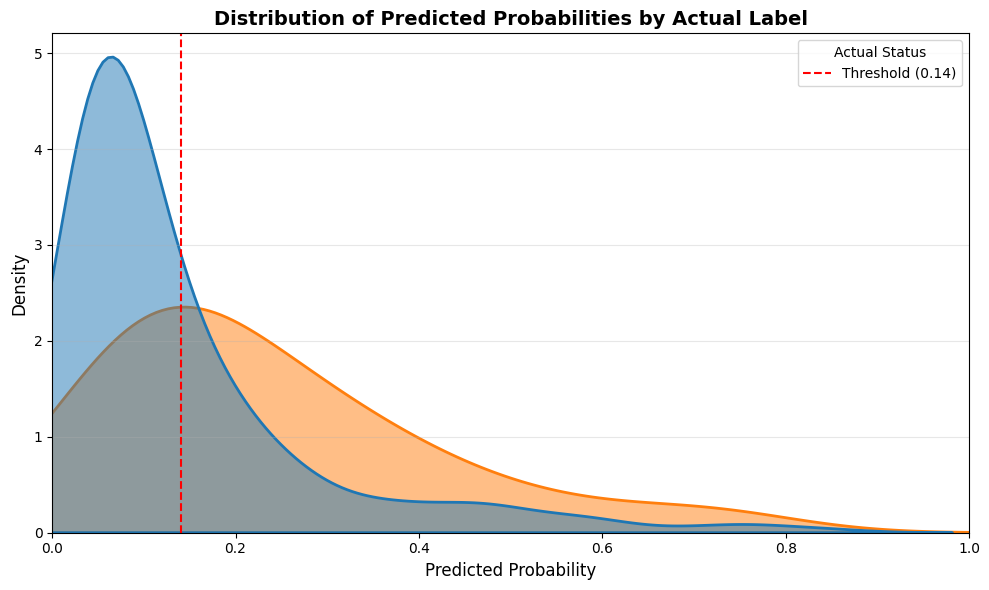

In [132]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create a temporary DataFrame for the plot
plot_df = pd.DataFrame({
    'Probability': np.squeeze(y_probs),
    'Label': np.squeeze(y_test_np)
})

print(y_probs[281:300])
print(y_test_np[281:300])

# 2. Map labels to names for a cleaner legend
plot_df['Label'] = plot_df['Label'].map({0: 'No Sepsis', 1: 'Sepsis'})

# 3. Create the figure
plt.figure(figsize=(10, 6))

# 4. Plot overlapping density curves (matching the screenshot style)
sns.kdeplot(
    data=plot_df,
    x='Probability',
    hue='Label',
    fill=True,           # Fills the area under the curve
    common_norm=False,   # Normalizes each curve independently (crucial for imbalanced data)
    palette={'No Sepsis': '#1f77b4', 'Sepsis': '#ff7f0e'}, # Blue and Orange
    alpha=0.5,           # Transparency for overlapping areas
    linewidth=2
)

# 5. Add the vertical threshold line
plt.axvline(x=threshold, color='red', linestyle='--', label=f'Threshold ({threshold})')

# 6. Formatting to match the screenshot
plt.title('Distribution of Predicted Probabilities by Actual Label', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Probability', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.xlim(0, 1) # Probability is always between 0 and 1
plt.legend(title='Actual Status')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [133]:
# saving demo data

demo_dir = '/content/drive/MyDrive/25 Fall/BME499 - Senior Capstone/499 Senior Project Group - RaGS/Video Demo Samples'

sample = pd.DataFrame(X_test_np[0,:]).transpose()
print(sample)
sample.to_csv(f"{output_dir}/neg_0.csv", index=False)

sample = pd.DataFrame(X_test_np[1,:]).transpose()
sample.to_csv(f"{output_dir}/neg_1.csv", index=False)

sample = pd.DataFrame(X_test_np[2,:]).transpose()
sample.to_csv(f"{output_dir}/neg_2.csv", index=False)

sample = pd.DataFrame(X_test_np[3,:]).transpose()
sample.to_csv(f"{output_dir}/neg_3.csv", index=False)


sample = pd.DataFrame(X_test_np[17,:]).transpose()
sample.to_csv(f"{output_dir}/pos_0.csv", index=False)

sample = pd.DataFrame(X_test_np[41,:]).transpose()
sample.to_csv(f"{output_dir}/pos_1.csv", index=False)

sample = pd.DataFrame(X_test_np[63,:]).transpose()
sample.to_csv(f"{output_dir}/pos_2.csv", index=False)

sample = pd.DataFrame(X_test_np[289,:]).transpose()
sample.to_csv(f"{output_dir}/pos_3.csv", index=False)



        0         1         2         3         4         5         6    \
0 -1.001877  4.042255  1.172252 -1.172252 -0.375374  0.701736 -0.445977   

       7         8         9    ...       936       937       938       939  \
0 -0.20559 -0.523221 -0.724427  ...  0.048918 -3.002754 -0.079743  0.216644   

        940       941       942       943       944       945  
0 -0.790171 -0.141327  0.650782 -0.113348  0.182071  0.183338  

[1 rows x 946 columns]


NameError: name 'output_dir' is not defined

In [ ]:
# Calculate precision and recall for all possible thresholds
precision, recall, thresholds = precision_recall_curve(y_test_np, y_probs)

# Find the threshold that gets us closest to 80% Recall
target_recall = 0.80
idx = np.where(recall >= target_recall)[0][-1]
clinical_threshold = thresholds[idx]

# Apply this threshold
optimized_preds = (y_probs >= clinical_threshold).astype(int)

print(f"Targeting {target_recall*100}% Recall...")
print(f"Required Threshold: {clinical_threshold:.4f}")
print("\n--- Results at Clinical Threshold ---")
print(classification_report(y_test_np, optimized_preds))

In [ ]:
# 4. Plotting Performance Curves
fpr, tpr, _ = roc_curve(y_test_np, y_probs)
roc_auc = auc(fpr, tpr)
precision, recall, _ = precision_recall_curve(y_test_np, y_probs)
auprc = average_precision_score(y_test_np, y_probs)

plt.figure(figsize=(14, 6))

# ROC Curve
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

# Precision-Recall Curve
plt.subplot(1, 2, 2)
plt.plot(recall, precision, color='teal', lw=2, label=f'AUPRC = {auprc:.3f}')
plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision (Positive Predictive Value)')
plt.title('Precision-Recall Curve')
plt.legend(loc="upper right")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Get feature names from your dataframe (adjust variable name if different)
feat_importances = pd.Series(xgb_balanced.feature_importances_, index=feature_cols)

plt.figure(figsize=(10, 6))
feat_importances.nlargest(15).plot(kind='barh', color='skyblue')
plt.title("Top 15 Predictors of Sepsis (XGBoost)")
plt.xlabel("Relative Importance")
plt.gca().invert_yaxis() # Highest importance on top
plt.show()

# LOW, MED, HIGH Classification

In [ ]:
import numpy as np
import pandas as pd

# 1. Define your clinical thresholds
# Lowering t_low helps move Sepsis patients out of "Low Risk"
t_low = 0.10
t_high = 0.50

# 2. Create the Risk Categories
def assign_risk(prob):
    if prob < t_low:
        return 'LOW'
    elif prob < t_high:
        return 'MEDIUM'
    else:
        return 'HIGH'

# Apply to your test probabilities
risk_results = pd.DataFrame({
    'Probability': np.squeeze(y_probs),
    'Actual': np.squeeze(y_test_np),
    'Risk_Level': [assign_risk(p) for p in y_probs]
})

# 3. Create a "Clinical Risk Matrix"
# This shows exactly where the Sepsis patients landed
risk_matrix = pd.crosstab(risk_results['Actual'], risk_results['Risk_Level'],
                          dropna=False).reindex(columns=['LOW', 'MEDIUM', 'HIGH'], fill_value=0)

risk_matrix.index = ['No Sepsis', 'Sepsis']
print("--- Clinical Risk Distribution ---")
print(risk_matrix)

# 4. Calculate the "Miss Rate" (Sepsis in Low Risk)
sepsis_total = risk_matrix.loc['Sepsis'].sum()
sepsis_in_low = risk_matrix.loc['Sepsis', 'LOW']
print(f"\nSepsis Patients Missed (Landed in LOW): {sepsis_in_low} out of {sepsis_total}")

In [ ]:
plt.figure(figsize=(12, 6))

# Plot the same density curves
sns.kdeplot(data=risk_results, x='Probability', hue='Actual', fill=True, common_norm=False, palette='tab10', alpha=0.4)

# Add the colored zones
plt.axvspan(0, t_low, color='green', alpha=0.1, label='Low Risk Zone')
plt.axvspan(t_low, t_high, color='orange', alpha=0.1, label='Medium Risk Zone')
plt.axvspan(t_high, 1, color='red', alpha=0.1, label='High Risk Zone')

# Add the threshold lines
plt.axvline(t_low, color='black', linestyle='--')
plt.axvline(t_high, color='black', linestyle='--')

plt.title('Sepsis Probability vs. Clinical Risk Zones', fontsize=14)
plt.xlabel('Model Probability')
plt.ylabel('Density')
plt.legend(title='Actual Status')
plt.show()

# GC Testing


In [ ]:
# ============================================================
# SEPSIS PREDICTION WITH PYTORCH (IMPROVED VERSION)
# ============================================================
# This notebook:
# 1. Loads structured feature CSV + label CSV
# 2. Merges them by HADM_ID
# 3. Cleans columns
# 4. Removes poor-quality features
# 5. Splits data into train / validation / test
# 6. Imputes missing values and standardizes features
# 7. Trains an MLP with class imbalance handling
# 8. Uses early stopping on validation AUPRC
# 9. Tunes the prediction threshold on validation set
# 10. Evaluates the final model on the test set
# 11. Saves the model + preprocessing artifacts
#
# You can paste this directly into Colab.
# ============================================================


# ============================================================
# 0) OPTIONAL: INSTALL / IMPORT LIBRARIES
# ============================================================
# Uncomment these only if torch is not already installed in Colab.
# !pip3 uninstall -y torchvision torchaudio torch
# !pip3 cache purge
# !pip3 install torch torchvision torchaudio

import os
import json
import copy
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


# ============================================================
# 1) REPRODUCIBILITY
# ============================================================
# This makes results more repeatable.
# Change SEED if you want a different random split/run.

SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)


# ============================================================
# 2) USER SETTINGS YOU MAY WANT TO CHANGE
# ============================================================
# These are the main knobs to tune.
# Start with these values first, then adjust later.

# ----- File paths -----
DATAPATH = '/content/drive/MyDrive/25 Fall/BME499 - Senior Capstone/499 Senior Project Group - RaGS/Code/CSV Files/'
FEATURE_FILE = 'all_features_table.csv'
LABEL_FILE = 'train4_small_sepsis_labels.csv'

FEATURE_PATH = f"{DATAPATH}/{FEATURE_FILE}"
LABEL_PATH   = f"{DATAPATH}processed CSVs/{LABEL_FILE}"

# ----- Key columns -----
ID_COL = "HADM_ID"
LABEL_COL = "SEPSIS_STATUS"

# ----- Data cleaning settings -----
# Drop columns with missing fraction > this threshold
# Example: 0.95 means if >95% missing, drop that feature
MAX_MISSING_FRAC = 0.95

# Drop columns whose variance is too tiny after imputation
MIN_STD = 1e-12

# ----- Train / val / test split -----
TRAIN_FRAC = 0.70
VAL_FRAC   = 0.15
TEST_FRAC  = 0.15

# ----- DataLoader settings -----
BATCH_SIZE_TRAIN = 64
BATCH_SIZE_EVAL  = 256

# ----- Model architecture -----
# Good starting model for tabular data
HIDDEN_DIMS = (64, 32)
DROPOUT = 0.20
USE_BATCHNORM = True

# ----- Optimization -----
LR = 5e-4
WEIGHT_DECAY = 1e-4
MAX_EPOCHS = 100

# ----- Early stopping -----
# Stop if validation AUPRC doesn't improve after this many epochs
PATIENCE = 10

# ----- Class imbalance tuning -----
# "auto" uses Nneg/Npos
# You can also set POS_WEIGHT_MULTIPLIER to 0.5, 1.0, 1.5, etc.
POS_WEIGHT_MULTIPLIER = 1.0

# ----- Threshold tuning -----
# We will pick the best threshold on the validation set
THRESHOLDS_TO_TRY = np.arange(0.10, 0.91, 0.05)

# ----- Optional repeated runs -----
# Set to 1 first while debugging.
N_RUNS = 1

# ----- Save paths -----
MODEL_SAVE_PATH = f"{DATAPATH}sepsis_mlp_improved.pt"
PREPROCESS_SAVE_PATH = f"{DATAPATH}sepsis_preprocess_improved.npz"
SUMMARY_SAVE_PATH = f"{DATAPATH}sepsis_training_summary_improved.json"


# ============================================================
# 3) HELPER FUNCTIONS
# ============================================================

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def confusion_counts(y_true, y_pred):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)

    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    return tp, tn, fp, fn

def precision_recall_f1(y_true, y_pred):
    tp, tn, fp, fn = confusion_counts(y_true, y_pred)

    acc = (tp + tn) / max(tp + tn + fp + fn, 1)
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "tp": tp,
        "tn": tn,
        "fp": fp,
        "fn": fn,
    }

def roc_auc_score_np(y_true, y_score):
    """
    Manual AUROC using rank statistic.
    Returns NaN if one class is missing.
    """
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)

    pos = y_true == 1
    neg = y_true == 0
    n_pos = pos.sum()
    n_neg = neg.sum()

    if n_pos == 0 or n_neg == 0:
        return float("nan")

    order = np.argsort(y_score)
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.arange(1, len(y_score) + 1)

    sorted_scores = y_score[order]
    i = 0
    while i < len(sorted_scores):
        j = i
        while j + 1 < len(sorted_scores) and sorted_scores[j + 1] == sorted_scores[i]:
            j += 1
        if j > i:
            avg_rank = ranks[order[i:j+1]].mean()
            ranks[order[i:j+1]] = avg_rank
        i = j + 1

    sum_ranks_pos = ranks[pos].sum()
    U = sum_ranks_pos - n_pos * (n_pos + 1) / 2
    auc = U / (n_pos * n_neg)
    return float(auc)

def average_precision_score_np(y_true, y_score):
    """
    Manual AUPRC / Average Precision.
    """
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)

    n_pos = (y_true == 1).sum()
    if n_pos == 0:
        return float("nan")

    order = np.argsort(-y_score)
    y_sorted = y_true[order]

    tp = np.cumsum(y_sorted == 1)
    fp = np.cumsum(y_sorted == 0)

    precision = tp / np.maximum(tp + fp, 1)
    ap = precision[y_sorted == 1].sum() / n_pos
    return float(ap)

def stratified_train_val_test_split(y, train_frac=0.7, val_frac=0.15, test_frac=0.15, seed=42):
    """
    Stratified split for binary classification.
    Returns train_idx, val_idx, test_idx.
    """
    assert abs(train_frac + val_frac + test_frac - 1.0) < 1e-8, "Fractions must sum to 1."

    y = np.asarray(y).astype(int)
    rng = np.random.default_rng(seed)

    idx0 = np.where(y == 0)[0]
    idx1 = np.where(y == 1)[0]

    rng.shuffle(idx0)
    rng.shuffle(idx1)

    def split_class_indices(idx):
        n = len(idx)
        n_train = int(round(n * train_frac))
        n_val = int(round(n * val_frac))
        n_test = n - n_train - n_val

        train_idx = idx[:n_train]
        val_idx   = idx[n_train:n_train+n_val]
        test_idx  = idx[n_train+n_val:]
        return train_idx, val_idx, test_idx

    tr0, va0, te0 = split_class_indices(idx0)
    tr1, va1, te1 = split_class_indices(idx1)

    train_idx = np.concatenate([tr0, tr1])
    val_idx   = np.concatenate([va0, va1])
    test_idx  = np.concatenate([te0, te1])

    rng.shuffle(train_idx)
    rng.shuffle(val_idx)
    rng.shuffle(test_idx)

    return train_idx, val_idx, test_idx

def impute_median_fit(X):
    med = np.nanmedian(X, axis=0)
    med = np.where(np.isnan(med), 0.0, med)
    return med

def impute_median_transform(X, med):
    X2 = X.copy()
    nan_mask = np.isnan(X2)
    if nan_mask.any():
        X2[nan_mask] = np.take(med, np.where(nan_mask)[1])
    return X2

def standardize_fit(X):
    mean = X.mean(axis=0)
    std = X.std(axis=0)
    std = np.where(std < MIN_STD, 1.0, std)
    return mean, std

def standardize_transform(X, mean, std):
    return (X - mean) / std

def pick_best_threshold(y_true, probs, thresholds):
    """
    Pick threshold using validation set.
    Here we maximize F1, but you could instead maximize recall
    or choose a threshold with minimum precision.
    """
    best = None

    for thr in thresholds:
        preds = (probs >= thr).astype(int)
        metrics = precision_recall_f1(y_true, preds)
        metrics["threshold"] = float(thr)

        if best is None or metrics["f1"] > best["f1"]:
            best = metrics

    return best

def compute_roc_curve_np(y_true, probs):
    """
    Manual ROC curve.
    """
    order = np.argsort(-probs)
    y_sorted = y_true[order]

    tp = np.cumsum(y_sorted == 1)
    fp = np.cumsum(y_sorted == 0)

    n_pos = max((y_true == 1).sum(), 1)
    n_neg = max((y_true == 0).sum(), 1)

    tpr = tp / n_pos
    fpr = fp / n_neg

    tpr = np.concatenate([[0.0], tpr, [1.0]])
    fpr = np.concatenate([[0.0], fpr, [1.0]])

    return fpr, tpr

def print_label_stats(name, y):
    y = np.asarray(y).astype(int)
    n = len(y)
    pos = int((y == 1).sum())
    neg = int((y == 0).sum())
    print(f"{name}: n={n}, neg={neg}, pos={pos}, pos_rate={pos/max(n,1):.4f}")


# ============================================================
# 4) LOAD DATA
# ============================================================

print("Loading data...")
features = pd.read_csv(FEATURE_PATH)
labels = pd.read_csv(LABEL_PATH)

# Standardize column names
features.columns = features.columns.str.strip().str.upper()
labels.columns = labels.columns.str.strip().str.upper()
ID_COL = ID_COL.upper()
LABEL_COL = LABEL_COL.upper()

# Standardize ID columns for safe merge
features[ID_COL] = features[ID_COL].astype("string").str.strip()
labels[ID_COL] = labels[ID_COL].astype("string").str.strip()

# Merge features + labels
data = features.merge(labels[[ID_COL, LABEL_COL]], on=ID_COL, how="inner")

print("Merged shape:", data.shape)
print(data[LABEL_COL].value_counts(dropna=False))


# ============================================================
# 5) BUILD FEATURE MATRIX
# ============================================================
# Convert all feature columns to numeric.
# Anything non-numeric becomes NaN.

feature_cols = [c for c in data.columns if c not in {ID_COL, LABEL_COL}]
X_df = data[feature_cols].apply(pd.to_numeric, errors="coerce")
y = data[LABEL_COL].astype(int).to_numpy()

print("\nInitial feature count:", X_df.shape[1])


# ============================================================
# 6) DROP VERY BAD COLUMNS
# ============================================================
# We remove:
# - columns with too much missingness
# - columns that are entirely NaN
#
# You may change MAX_MISSING_FRAC.
# Lower = stricter filtering
# Higher = keep more columns

missing_frac = X_df.isna().mean(axis=0)
keep_missing = missing_frac <= MAX_MISSING_FRAC
X_df = X_df.loc[:, keep_missing]

print("Feature count after missingness filter:", X_df.shape[1])

# Drop columns that are entirely NaN after numeric conversion
all_nan_cols = X_df.columns[X_df.isna().all(axis=0)]
if len(all_nan_cols) > 0:
    print("Dropping all-NaN columns:", len(all_nan_cols))
    X_df = X_df.drop(columns=all_nan_cols)

print("Feature count after all-NaN drop:", X_df.shape[1])

feature_cols = list(X_df.columns)


# ============================================================
# 7) TRAIN / VAL / TEST SPLIT
# ============================================================
train_idx, val_idx, test_idx = stratified_train_val_test_split(
    y,
    train_frac=TRAIN_FRAC,
    val_frac=VAL_FRAC,
    test_frac=TEST_FRAC,
    seed=SEED
)

X = X_df.to_numpy(dtype=np.float32)

X_train_raw, y_train = X[train_idx], y[train_idx]
X_val_raw,   y_val   = X[val_idx],   y[val_idx]
X_test_raw,  y_test  = X[test_idx],  y[test_idx]

print("\nSplit sizes:")
print("Train:", X_train_raw.shape)
print("Val  :", X_val_raw.shape)
print("Test :", X_test_raw.shape)

print_label_stats("Train", y_train)
print_label_stats("Val", y_val)
print_label_stats("Test", y_test)


# ============================================================
# 8) FIT PREPROCESSING ON TRAIN ONLY
# ============================================================
# This prevents leakage from validation/test into training.

# ---- Median imputation ----
med = impute_median_fit(X_train_raw)

X_train_imp = impute_median_transform(X_train_raw, med)
X_val_imp   = impute_median_transform(X_val_raw, med)
X_test_imp  = impute_median_transform(X_test_raw, med)

# ---- Drop constant / near-constant columns after imputation ----
train_std_after_impute = X_train_imp.std(axis=0)
keep_var = train_std_after_impute > MIN_STD

X_train_imp = X_train_imp[:, keep_var]
X_val_imp   = X_val_imp[:, keep_var]
X_test_imp  = X_test_imp[:, keep_var]

feature_cols_filtered = [c for c, k in zip(feature_cols, keep_var) if k]

print("\nFeature count after constant-column drop:", len(feature_cols_filtered))

# ---- Standardization ----
mean, std = standardize_fit(X_train_imp)

X_train_proc = standardize_transform(X_train_imp, mean, std)
X_val_proc   = standardize_transform(X_val_imp, mean, std)
X_test_proc  = standardize_transform(X_test_imp, mean, std)

# ---- Convert to PyTorch tensors ----
X_train_t = torch.tensor(X_train_proc, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

X_val_t = torch.tensor(X_val_proc, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

X_test_t = torch.tensor(X_test_proc, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)


# ============================================================
# 9) DATASET / DATALOADER
# ============================================================

class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = TabularDataset(X_train_t, y_train_t)
val_ds   = TabularDataset(X_val_t, y_val_t)
test_ds  = TabularDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE_TRAIN, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE_EVAL, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE_EVAL, shuffle=False)


# ============================================================
# 10) MODEL DEFINITION
# ============================================================
# This is an improved MLP for tabular data.
#
# Things you may change:
# - HIDDEN_DIMS: smaller or larger hidden layers
# - DROPOUT: try 0.1, 0.2, 0.3
# - USE_BATCHNORM: True/False

class MLP(nn.Module):
    def __init__(self, in_dim, hidden_dims=(64, 32), dropout=0.2, use_batchnorm=True):
        super().__init__()

        layers = []
        prev = in_dim

        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(nn.LeakyReLU(0.01))
            layers.append(nn.Dropout(dropout))
            prev = h

        layers.append(nn.Linear(prev, 1))  # raw logits
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


# ============================================================
# 11) EVALUATION FUNCTION
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("\nUsing device:", device)

def eval_model(model, loader, device):
    model.eval()

    all_logits = []
    all_y = []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits = model(xb).cpu().numpy().reshape(-1)
            all_logits.append(logits)
            all_y.append(yb.cpu().numpy().reshape(-1))

    logits = np.concatenate(all_logits)
    ytrue = np.concatenate(all_y).astype(int)
    probs = sigmoid(logits)

    return logits, ytrue, probs


# ============================================================
# 12) TRAINING FUNCTION WITH EARLY STOPPING
# ============================================================
# Early stopping uses validation AUPRC.
# That is more appropriate than accuracy for imbalanced data.

def train_one_model(
    X_train_t, y_train_t,
    X_val_t, y_val_t,
    input_dim,
    hidden_dims=HIDDEN_DIMS,
    dropout=DROPOUT,
    use_batchnorm=USE_BATCHNORM,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    pos_weight_multiplier=POS_WEIGHT_MULTIPLIER,
    seed=SEED
):
    set_seed(seed)

    # Build a fresh model
    model = MLP(
        in_dim=input_dim,
        hidden_dims=hidden_dims,
        dropout=dropout,
        use_batchnorm=use_batchnorm
    ).to(device)

    # Compute positive class weight for imbalance handling
    y_train_np = y_train_t.cpu().numpy().reshape(-1).astype(int)
    pos = float((y_train_np == 1).sum())
    neg = float((y_train_np == 0).sum())

    base_pos_weight = neg / max(pos, 1.0)
    pos_weight_value = base_pos_weight * pos_weight_multiplier

    pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32).to(device)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    # Track history for plots
    history = {
        "train_loss": [],
        "val_auprc": [],
        "val_auroc": [],
        "val_f1_best_thr": [],
        "best_thr_each_epoch": [],
    }

    best_model_state = None
    best_val_auprc = -np.inf
    best_epoch = -1
    epochs_without_improvement = 0

    # Create train loader inside function to keep things clean
    train_ds_local = TabularDataset(X_train_t, y_train_t)
    train_loader_local = DataLoader(train_ds_local, batch_size=BATCH_SIZE_TRAIN, shuffle=True)

    val_ds_local = TabularDataset(X_val_t, y_val_t)
    val_loader_local = DataLoader(val_ds_local, batch_size=BATCH_SIZE_EVAL, shuffle=False)

    for epoch in range(1, max_epochs + 1):
        model.train()
        running_loss = 0.0

        for xb, yb in train_loader_local:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * xb.size(0)

        train_loss = running_loss / len(train_ds_local)

        # Evaluate on validation set
        val_logits, val_ytrue, val_probs = eval_model(model, val_loader_local, device)
        val_auprc = average_precision_score_np(val_ytrue, val_probs)
        val_auroc = roc_auc_score_np(val_ytrue, val_probs)

        best_thr_metrics = pick_best_threshold(val_ytrue, val_probs, THRESHOLDS_TO_TRY)

        history["train_loss"].append(train_loss)
        history["val_auprc"].append(val_auprc)
        history["val_auroc"].append(val_auroc)
        history["val_f1_best_thr"].append(best_thr_metrics["f1"])
        history["best_thr_each_epoch"].append(best_thr_metrics["threshold"])

        print(
            f"Epoch {epoch:03d} | "
            f"train_loss={train_loss:.4f} | "
            f"val_AUPRC={val_auprc:.4f} | "
            f"val_AUROC={val_auroc:.4f} | "
            f"val_bestF1={best_thr_metrics['f1']:.4f} @ thr={best_thr_metrics['threshold']:.2f}"
        )

        # Early stopping monitors validation AUPRC
        if val_auprc > best_val_auprc:
            best_val_auprc = val_auprc
            best_epoch = epoch
            epochs_without_improvement = 0
            best_model_state = copy.deepcopy(model.state_dict())
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"Early stopping at epoch {epoch}. Best epoch was {best_epoch}.")
            break

    # Restore best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    # Final validation outputs from the best saved model
    val_logits, val_ytrue, val_probs = eval_model(model, val_loader_local, device)
    best_val_thr_metrics = pick_best_threshold(val_ytrue, val_probs, THRESHOLDS_TO_TRY)
    best_threshold = best_val_thr_metrics["threshold"]

    training_summary = {
        "best_epoch": best_epoch,
        "best_val_auprc": float(best_val_auprc),
        "best_threshold": float(best_threshold),
        "pos_weight_value": float(pos_weight_value),
    }

    return model, history, training_summary


# ============================================================
# 13) FINAL TEST EVALUATION
# ============================================================

def evaluate_with_threshold(model, X_t, y_t, threshold, split_name="Test"):
    ds = TabularDataset(X_t, y_t)
    loader = DataLoader(ds, batch_size=BATCH_SIZE_EVAL, shuffle=False)

    logits, ytrue, probs = eval_model(model, loader, device)
    preds = (probs >= threshold).astype(int)

    clf_metrics = precision_recall_f1(ytrue, preds)
    auroc = roc_auc_score_np(ytrue, probs)
    auprc = average_precision_score_np(ytrue, probs)

    results = {
        "split": split_name,
        "threshold": float(threshold),
        "accuracy": float(clf_metrics["accuracy"]),
        "precision": float(clf_metrics["precision"]),
        "recall": float(clf_metrics["recall"]),
        "f1": float(clf_metrics["f1"]),
        "tp": int(clf_metrics["tp"]),
        "tn": int(clf_metrics["tn"]),
        "fp": int(clf_metrics["fp"]),
        "fn": int(clf_metrics["fn"]),
        "auroc": float(auroc),
        "auprc": float(auprc),
    }

    return results, logits, ytrue, probs, preds


# ============================================================
# 14) RUN TRAINING
# ============================================================

all_run_results = []

for run in range(N_RUNS):
    print("\n" + "="*70)
    print(f"RUN {run+1}/{N_RUNS}")
    print("="*70)

    run_seed = SEED + run

    model, history, training_summary = train_one_model(
        X_train_t=X_train_t,
        y_train_t=y_train_t,
        X_val_t=X_val_t,
        y_val_t=y_val_t,
        input_dim=X_train_t.shape[1],
        hidden_dims=HIDDEN_DIMS,
        dropout=DROPOUT,
        use_batchnorm=USE_BATCHNORM,
        lr=LR,
        weight_decay=WEIGHT_DECAY,
        max_epochs=MAX_EPOCHS,
        patience=PATIENCE,
        pos_weight_multiplier=POS_WEIGHT_MULTIPLIER,
        seed=run_seed,
    )

    # Evaluate on validation set using the chosen threshold
    best_threshold = training_summary["best_threshold"]

    val_results, _, _, _, _ = evaluate_with_threshold(
        model, X_val_t, y_val_t, threshold=best_threshold, split_name="Validation"
    )

    test_results, test_logits, test_ytrue, test_probs, test_preds = evaluate_with_threshold(
        model, X_test_t, y_test_t, threshold=best_threshold, split_name="Test"
    )

    print("\nValidation results:")
    print(val_results)

    print("\nTest results:")
    print(test_results)

    all_run_results.append({
        "run": run + 1,
        "seed": run_seed,
        "training_summary": training_summary,
        "val_results": val_results,
        "test_results": test_results,
        "history": history,
    })


# ============================================================
# 15) SUMMARIZE RESULTS
# ============================================================

def summarize_runs(all_run_results):
    test_metrics_keys = ["accuracy", "precision", "recall", "f1", "auroc", "auprc"]

    summary = {}
    for key in test_metrics_keys:
        vals = np.array([r["test_results"][key] for r in all_run_results], dtype=float)
        summary[key] = {
            "mean": float(vals.mean()),
            "std": float(vals.std()),
        }

    return summary

summary = summarize_runs(all_run_results)

print("\n" + "="*70)
print("FINAL SUMMARY ACROSS RUNS")
print("="*70)

for metric, vals in summary.items():
    print(f"{metric:10s} = {vals['mean']:.4f} \u00b1 {vals['std']:.4f}")


# ============================================================
# 16) SAVE BEST MODEL + PREPROCESSING
# ============================================================
# For now, if N_RUNS > 1, this saves the last run's model.
# You could later modify this to save the best run by test/val AUPRC.

torch.save(model.state_dict(), MODEL_SAVE_PATH)

np.savez(
    PREPROCESS_SAVE_PATH,
    median=med,
    keep_var=keep_var,
    mean=mean,
    std=std,
    feature_names=np.array(feature_cols_filtered, dtype=object),
    best_threshold=np.array([training_summary["best_threshold"]], dtype=np.float32),
)

with open(SUMMARY_SAVE_PATH, "w") as f:
    json.dump(
        {
            "settings": {
                "SEED": SEED,
                "MAX_MISSING_FRAC": MAX_MISSING_FRAC,
                "TRAIN_FRAC": TRAIN_FRAC,
                "VAL_FRAC": VAL_FRAC,
                "TEST_FRAC": TEST_FRAC,
                "BATCH_SIZE_TRAIN": BATCH_SIZE_TRAIN,
                "BATCH_SIZE_EVAL": BATCH_SIZE_EVAL,
                "HIDDEN_DIMS": list(HIDDEN_DIMS),
                "DROPOUT": DROPOUT,
                "USE_BATCHNORM": USE_BATCHNORM,
                "LR": LR,
                "WEIGHT_DECAY": WEIGHT_DECAY,
                "MAX_EPOCHS": MAX_EPOCHS,
                "PATIENCE": PATIENCE,
                "POS_WEIGHT_MULTIPLIER": POS_WEIGHT_MULTIPLIER,
                "THRESHOLDS_TO_TRY": list(map(float, THRESHOLDS_TO_TRY)),
                "N_RUNS": N_RUNS,
            },
            "summary": summary,
            "all_run_results": all_run_results,
        },
        f,
        indent=2
    )

print("\nSaved model to:", MODEL_SAVE_PATH)
print("Saved preprocessing to:", PREPROCESS_SAVE_PATH)
print("Saved training summary to:", SUMMARY_SAVE_PATH)


# ============================================================
# 17) PLOT TRAINING CURVES
# ============================================================

last_history = all_run_results[-1]["history"]

plt.figure(figsize=(8, 5))
plt.plot(last_history["train_loss"])
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("Training Loss")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(last_history["val_auprc"], label="Val AUPRC")
plt.plot(last_history["val_auroc"], label="Val AUROC")
plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.title("Validation Metrics")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(last_history["val_f1_best_thr"])
plt.xlabel("Epoch")
plt.ylabel("Validation Best F1")
plt.title("Best Validation F1 per Epoch")
plt.show()


# ============================================================
# 18) PLOT TEST ROC CURVE
# ============================================================

fpr, tpr = compute_roc_curve_np(test_ytrue, test_probs)
test_auroc = roc_auc_score_np(test_ytrue, test_probs)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"Test ROC Curve (AUROC = {test_auroc:.4f})")
plt.show()


# ============================================================
# 19) PLOT TEST PROBABILITY DISTRIBUTION BY TRUE CLASS
# ============================================================

probs_neg = test_probs[test_ytrue == 0]
probs_pos = test_probs[test_ytrue == 1]

plt.figure(figsize=(8, 5))
plt.hist(probs_neg, bins=30, alpha=0.6, label="True 0")
plt.hist(probs_pos, bins=30, alpha=0.6, label="True 1")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("Test Probability Distribution by True Class")
plt.legend()
plt.show()


# ============================================================
# 20) PLOT CONFUSION-GROUP SCATTER
# ============================================================
# This helps visualize true negatives, false positives, etc.

probs_00 = test_probs[(test_ytrue == 0) & (test_preds == 0)]  # TN
probs_01 = test_probs[(test_ytrue == 0) & (test_preds == 1)]  # FP
probs_10 = test_probs[(test_ytrue == 1) & (test_preds == 0)]  # FN
probs_11 = test_probs[(test_ytrue == 1) & (test_preds == 1)]  # TP

x_00 = np.zeros(len(probs_00))
x_01 = np.zeros(len(probs_01))
x_10 = np.ones(len(probs_10))
x_11 = np.ones(len(probs_11))

plt.figure(figsize=(8, 4))
plt.scatter(probs_00, x_00, alpha=0.35, label="TN")
plt.scatter(probs_01, x_01, alpha=0.35, label="FP")
plt.scatter(probs_10, x_10, alpha=0.35, label="FN")
plt.scatter(probs_11, x_11, alpha=0.35, label="TP")
plt.xlabel("Predicted Probability")
plt.ylabel("True Sepsis Label")
plt.title("Probability Scatter by True/Predicted Group")
plt.xlim([0, 1])
plt.legend()
plt.show()

In [ ]:
# FOR GC


# Save the model
# xgb_balanced.save_model("sepsis_risk_model.json")
# print("Model exported as sepsis_risk_model.json")



#    CODE FOR THE GUI SECTION

import xgboost as xgb
import numpy as np

# 1. Load the model in your GUI script
model = xgb.XGBClassifier()
model.load_model("sepsis_risk_model.json")

# 2. Define your clinical thresholds
T_LOW = 0.10
T_HIGH = 0.50

def get_clinical_risk(patient_data):
    """
    patient_data: a 2D numpy array or DataFrame with your 970 features
    """
    # Get the raw probability from the model
    prob = model.predict_proba(patient_data)[0, 1]

    # Apply the 3-way logic
    if prob < T_LOW:
        return "LOW RISK", "green", prob
    elif prob < T_HIGH:
        return "MEDIUM RISK", "orange", prob
    else:
        return "HIGH RISK", "red", prob



# TESTING usage in GUI:

file = 'neg_0.csv'
path = f"/content/drive/MyDrive/25 Fall/BME499 - Senior Capstone/499 Senior Project Group - RaGS/Video Demo Samples/{file}"

new_patient_features = pd.read_csv(path)
print(new_patient_features)
print(new_patient_features.shape)

risk_label, color, p = get_clinical_risk(new_patient_features)
print("RISK: ", risk_label)
print("prob: ", p)


# Creating Demo CSVs




In [ ]:
# selecting a mix of sepsis positive and sepsis negatives


import os
import pandas as pd

file = 'train1_combined_latest_note_1_hadm18hrs.csv'
path = f"/content/drive/MyDrive/25 Fall/BME499 - Senior Capstone/499 Senior Project Group - RaGS/Code/CSV Files/processed CSVs/{file}"
df4 = pd.read_csv(path)
df4.rename(columns={df4.columns[0]: "HADM_ID"}, inplace=True)
print(df4.columns)
print("set4 limited:", df4.shape)

path = f'{datapath}/processed CSVs/set 1/train1_small_sepsis_labels.csv'
labels = pd.concat([labels, pd.read_csv(path)], ignore_index=True)
print(labels.columns)


output_dir = '/content/drive/MyDrive/25 Fall/BME499 - Senior Capstone/499 Senior Project Group - RaGS/Video Demo Samples'


os.makedirs(output_dir, exist_ok=True)

# make sure the ID column name is correct
id_col = "HADM_ID"   # change to "hadm_id" if that is your actual column name
label_col = "SEPSIS_STATUS" # change if needed

# split IDs by class from labels
pos_ids = labels.loc[labels[label_col] == 1, id_col]
neg_ids = labels.loc[labels[label_col] == 0, id_col]

# sample 10 of each
pos_ids = pos_ids.sample(10, random_state=42)
print(type(pos_ids))
print(pos_ids.shape)
print(pos_ids.tolist())
neg_ids = neg_ids.sample(10, random_state=42)
print(neg_ids)


# save positive rows from df4
for hadm_id in pos_ids:
    sample = df4[df4[id_col] == hadm_id]
    sample.to_csv(f"{output_dir}/pos_{hadm_id}.csv", index=False)

# save negative rows from df4
for hadm_id in neg_ids:
    sample = df4[df4[id_col] == hadm_id]
    sample.to_csv(f"{output_dir}/neg_{hadm_id}.csv", index=False)



In [ ]:
features = features.reset_index(drop=True)
labels = labels.reset_index(drop=True)

pos_idx = labels[labels[LABEL_COL] == 1].index[:10]
neg_idx = labels[labels[LABEL_COL] == 0].index[:10]

pos_samples = features.loc[pos_idx]
neg_samples = features.loc[neg_idx]

samples = pd.concat([pos_samples, neg_samples], ignore_index=True)
print(samples.shape)

import os
output_dir = '/content/drive/MyDrive/25 Fall/BME499 - Senior Capstone/499 Senior Project Group - RaGS/Video Demo Samples'
os.makedirs(output_dir, exist_ok=True)

for i, idx in enumerate(pos_idx):
    features.loc[[idx]].to_csv(f"{output_dir}/pos_{i}.csv", index=False)

for i, idx in enumerate(neg_idx):
    features.loc[[idx]].to_csv(f"{output_dir}/neg_{i}.csv", index=False)